# Superconductivity Tc Extraction Pipeline + Snippet Verification

Same pipeline as `superconductivity_tc_extraction.ipynb`, but with an enhanced
VLM Tc extraction step (Step 7) that sends **both the full R(T) plot AND a
cropped bottom-left quadrant** in a single Claude call.

**Why?** The VLM struggles with scale on wide-range plots (0-300K) where the
superconducting transition is a tiny feature. By also providing a ~4x zoomed
crop of the bottom-left (where R→0 transitions live), the VLM can verify its
scale reading and refine T_onset/T_zero with better pixel resolution.

## Changes from base notebook
- **Step 7 only**: VLM now receives 2 images (full + bottom-left crop) in one call
- All other steps (0-6, 8-9) are identical


## Setup

In [308]:
# ==============================================================================
# USER CONFIGURATION
# ==============================================================================

# Path to your superconductivity paper (PDF or markdown)
#INPUT_PATH = "/Users/valeriegentzke/Desktop/try_paper.pdf"  # <-- CHANGE THIS
INPUT_PATH = "/Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/data/pdf_papers/superconductor_pdfs-random-sample/selected_papers/0804.0835_0804.0835v2.pdf"  # or .md file with embedded images

# Output directory for results (inside the PDF papers folder)
PDF_DIR = "/Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/data/pdf_papers/superconductor_pdfs-random-sample/selected_papers"
OUTPUT_DIR = f"{PDF_DIR}/results"

# Master CSV for multi-paper aggregation (appended after each run)
MASTER_CSV = f"{OUTPUT_DIR}/tc_master.csv"

# Models
GEMINI_MODEL = "gemini-3.0-flash"      # For synthesis / Tc text extraction
CLAUDE_MODEL = "claude-sonnet-4-6"    #"claude-sonnet-4-20250514"  # For VLM plot data + Tc extraction
LINKER_MODEL = "gemini-3.0-flash"      # For series-to-material matching

# Set to True to skip figure extraction (synthesis + Tc text only)
SKIP_FIGURES = False

In [309]:
# Load environment and imports
import os
import sys
import ssl
import json
import re
import warnings
from pathlib import Path

# ── Fast dependency check (fail early, not at Step 4) ──
def _check_dependencies():
    """Verify critical dependencies are installed and compatible before running the pipeline."""
    errors = []
    
    # Check transformers + CLIP (needed for Florence-2 figure extraction)
    try:
        from transformers import CLIPImageProcessor  # noqa: F401
    except (ImportError, ModuleNotFoundError):
        try:
            import transformers
            ver = transformers.__version__
        except Exception:
            ver = "unknown"
        errors.append(
            f"transformers.CLIPImageProcessor not found (transformers=={ver}).\n"
            f"   Fix: pip install --upgrade transformers\n"
            f"   Or:  uv pip install --upgrade transformers"
        )
    
    # Check anthropic SDK (needed for Claude VLM calls)
    try:
        import anthropic  # noqa: F401
    except ImportError:
        errors.append("anthropic SDK not installed. Fix: pip install anthropic")
    
    # Check dspy (needed for text extraction)
    try:
        import dspy  # noqa: F401
    except ImportError:
        errors.append("dspy not installed. Fix: pip install dspy")
    
    if errors:
        print("=" * 60)
        print("DEPENDENCY CHECK FAILED")
        print("=" * 60)
        for e in errors:
            print(f"  ✗ {e}")
        print("=" * 60)
        raise ImportError("Fix the above dependencies before running the pipeline.")
    else:
        print("[OK] Dependency check passed (transformers/CLIP, anthropic, dspy)")

_check_dependencies()

# Fix SSL certificate issue for uv-managed Python on macOS
# The httpx client (used by anthropic SDK) may fail to find SSL certs
_ssl_cert = ssl.get_default_verify_paths().cafile
if _ssl_cert and os.path.exists(_ssl_cert):
    os.environ.setdefault("SSL_CERT_FILE", _ssl_cert)
    os.environ.setdefault("SSL_CERT_DIR", os.path.dirname(_ssl_cert))

src_path = Path("../../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from dotenv import load_dotenv
env_path = Path("../../.env")
load_dotenv(env_path, override=True)

warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

import logging
logging.getLogger("pydantic").setLevel(logging.ERROR)
logging.getLogger("LiteLLM").setLevel(logging.ERROR)
logging.getLogger("litellm").setLevel(logging.ERROR)

print("[OK] Environment loaded")
print(f"[OK] src path: {src_path}")
print(f"[OK] SSL_CERT_FILE: {os.environ.get('SSL_CERT_FILE', 'not set')}")

[OK] Dependency check passed (transformers/CLIP, anthropic, dspy)
[OK] Environment loaded
[OK] src path: /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/src
[OK] SSL_CERT_FILE: /private/etc/ssl/cert.pem


### Full Pipeline

**Run order:** Cell 2 (config) → Cell 3 (imports) → Cell 5 (load + materials) → Cells 11-12 (synthesis) → Cell 14-15 (Tc text) → Cells 17-26 (figures + VLM) → Cell 28 (linking) → Cell 30 (aggregate) → Cell 32 (save) → Cell 34 (CSV export)

Cells 7 and 9 are the original Step 0/1 (load + materials) — kept for reference but superseded by Cell 5.

In [310]:
# ══════════════════════════════════════════════════════════════════════════
# FAST SETUP — Load paper text (Step 0) + Extract materials (Step 1)
# Synthesis, Tc text, figures, and VLM are in subsequent cells.
# ══════════════════════════════════════════════════════════════════════════
from llm_synthesis.models.paper import Paper
from llm_synthesis.transformers.material_extraction.dspy_extraction import (
    DspyTextExtractor,
    make_dspy_text_extractor_signature,
)
from llm_synthesis.utils.dspy_utils import get_llm_from_name
from llm_synthesis.utils.markdown_utils import clean_text

input_path = Path(INPUT_PATH)

# ── Extract text from PDF (Step 0) ──
if input_path.suffix.lower() == ".pdf":
    from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor
    pdf_extractor = MistralPDFExtractor(structured=False)
    with open(input_path, "rb") as f:
        paper_text = pdf_extractor.forward(f.read())
    print(f"[OK] Extracted text from PDF: {len(paper_text):,} chars")
elif input_path.suffix.lower() in (".md", ".txt"):
    paper_text = input_path.read_text(errors="replace")
    print(f"[OK] Loaded text: {len(paper_text):,} chars")
else:
    raise ValueError(f"Unsupported file type: {input_path.suffix}")

# ── Look for SI file ──
SI_PATTERNS = ["_SI", "-SI", "_si", "-si", "_Supporting", "_supporting",
               "_Supplementary", "_supplementary", "_supp", "_Supp"]
si_text = ""
for pattern in SI_PATTERNS:
    for ext in [".pdf", ".md", ".txt"]:
        si_path = input_path.parent / f"{input_path.stem}{pattern}{ext}"
        if si_path.exists():
            print(f"   Found SI: {si_path.name}")
            break
    else:
        continue
    break

# ── Create Paper object ──
paper = Paper(
    name=input_path.stem,
    id=input_path.stem,
    publication_text=paper_text,
    si_text=si_text,
)
print(f"[OK] Paper: {paper.id}")

# ── Clean text for LLM input ──
text_for_llm = clean_text(paper.publication_text)
print(f"[OK] text_for_llm: {len(text_for_llm):,} chars")

# ── Extract materials (Step 1) ──
material_sig = make_dspy_text_extractor_signature(
    instructions=(
        "Extract ALL distinct superconducting material compositions that were synthesized "
        "and tested in this paper. If the paper studies multiple variants "
        "(e.g., different doping levels x=0.1, x=0.2, x=0.3), list EACH variant "
        "as a separate material."
    ),
    output_name="materials",
    output_description=(
        "ALL distinct synthesized material compositions as a comma-separated list "
        "using chemical formulas. Include doping levels and stoichiometry."
    ),
)
material_lm = get_llm_from_name(
    "gemini-3.0-pro",
    model_kwargs={"temperature": 0.0, "max_tokens": 16000},
)
material_extractor = DspyTextExtractor(signature=material_sig, lm=material_lm)
materials_text = material_extractor.forward(input=text_for_llm)
materials = [m.strip() for m in materials_text.replace("\n", ",").split(",") if m.strip()]
print(f"[OK] Found {len(materials)} materials: {materials[:15]}{'...' if len(materials) > 15 else ''}")


2026/02/24 19:07:55 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


[OK] Extracted text from PDF: 236,386 chars
[OK] Paper: 0804.0835_0804.0835v2
[OK] text_for_llm: 10,375 chars
[OK] Found 2 materials: ['GdO0.85F0.15FeAs', 'GdO0.83F0.17FeAs']


---
## Step 0: Load Paper Text

In [311]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

from llm_synthesis.models.paper import Paper

# SI file detection helpers (same as synthesis_with_performance.ipynb)
SI_PATTERNS = ["_SI", "-SI", "_si", "-si", "_Supporting", "_supporting",
               "_Supplementary", "_supplementary", "_supp", "_Supp"]


def find_si_file(main_paper_path: Path) -> Path | None:
    parent_dir = main_paper_path.parent
    main_stem = main_paper_path.stem
    for pattern in SI_PATTERNS:
        for ext in [".pdf", ".md", ".txt"]:
            si_path = parent_dir / f"{main_stem}{pattern}{ext}"
            if si_path.exists():
                return si_path
    return None


def load_file_text(path: Path, pdf_extractor=None) -> str:
    suffix = path.suffix.lower()
    if suffix == ".pdf":
        if pdf_extractor is None:
            from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor
            pdf_extractor = MistralPDFExtractor(structured=False)
        with open(path, "rb") as f:
            return pdf_extractor.forward(f.read())
    elif suffix in [".md", ".txt"]:
        with open(path, "r", errors="replace") as f:
            return f.read()
    else:
        raise ValueError(f"Unsupported file type: {suffix}")


# Load main paper
input_path = Path(INPUT_PATH)
pdf_extractor = None

if input_path.suffix.lower() == ".pdf":
    print(f"Extracting text from PDF: {input_path.name}")
    from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor
    pdf_extractor = MistralPDFExtractor(structured=False)
    paper_text = load_file_text(input_path, pdf_extractor)
    print(f"   Main paper: {len(paper_text):,} characters")
elif input_path.suffix.lower() in [".md", ".txt"]:
    print(f"Loading markdown: {input_path.name}")
    paper_text = load_file_text(input_path)
    print(f"   Main paper: {len(paper_text):,} characters")
else:
    raise ValueError(f"Unsupported input type: {input_path}")

# Load SI file if exists
si_text = ""
si_path = find_si_file(input_path)
if si_path:
    print(f"   Found SI file: {si_path.name}")
    try:
        si_text = load_file_text(si_path, pdf_extractor)
        print(f"   SI text: {len(si_text):,} characters")
    except Exception as e:
        print(f"   [WARN] Failed to load SI file: {e}")

# Create Paper object
paper = Paper(
    name=input_path.stem,
    id=input_path.stem,
    publication_text=paper_text,
    si_text=si_text,
)

print(f"\n[OK] Paper loaded: {paper.name}")
print(f"   Main text: {len(paper.publication_text):,} chars")
print(f"   SI text: {len(paper.si_text):,} chars")

Extracting text from PDF: 0804.0835_0804.0835v2.pdf
   Main paper: 236,377 characters

[OK] Paper loaded: 0804.0835_0804.0835v2
   Main text: 236,377 chars
   SI text: 0 chars


---
## Step 1: Extract Materials

In [312]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# from llm_synthesis.transformers.material_extraction.dspy_extraction import (
#     DspyTextExtractor,
#     make_dspy_text_extractor_signature,
# )
# from llm_synthesis.utils.dspy_utils import get_llm_from_name
# from llm_synthesis.utils.markdown_utils import clean_text

# material_sig = make_dspy_text_extractor_signature(
#     instructions=(
#         "Extract ALL distinct superconducting material compositions that were synthesized "
#         "and tested in this paper. IMPORTANT: If the paper studies multiple variants "
#         "(e.g., different doping levels x=0.1, x=0.2, x=0.3), list EACH variant "
#         "as a separate material. Focus on materials that were actually synthesized, "
#         "not just mentioned or referenced from other works."
#     ),
#     output_name="materials",
#     output_description=(
#         "ALL distinct synthesized material compositions as a comma-separated list "
#         "using chemical formulas. Include doping levels, substitution amounts, and "
#         "stoichiometry when specified (e.g., 'Ba0.6K0.4Fe2As2, Ba0.85La0.15Fe2As2'). "
#         "Never merge variants into a single generic name."
#     ),
# )

# material_lm = get_llm_from_name(
#     "gemini-3.0-pro",
#     model_kwargs={"temperature": 0.0, "max_tokens": 8000},
# )
# material_extractor = DspyTextExtractor(signature=material_sig, lm=material_lm)

# print("Extracting materials...")
# materials_text = material_extractor.forward(input=clean_text(paper.publication_text))

# materials = [
#     m.strip()
#     for m in materials_text.replace("\n", ",").split(",")
#     if m.strip()
# ]

# print(f"\n{'=' * 60}")
# print(f"MATERIALS FOUND ({len(materials)} total)")
# print("=" * 60)
# for i, mat in enumerate(materials, 1):
#     print(f"  {i}. {mat}")

---
## Step 2: Extract Synthesis Procedures

In [313]:
from llm_synthesis.transformers.synthesis_extraction.dspy_synthesis_extraction import (
    DspySynthesisExtractor,
    make_dspy_synthesis_extractor_signature,
)
from llm_synthesis.metrics.judge.general_synthesis_judge import (
    DspyGeneralSynthesisJudge,
    make_general_synthesis_judge_signature,
)

SYNTHESIS_SYSTEM_PROMPT = """You are a helpful assistant that extracts structured synthesis procedures from scientific papers.

IMPORTANT: For the synthesis_method field, you MUST choose from these exact values:
'PVD', 'CVD', 'arc discharge', 'ball milling', 'spray pyrolysis', 'electrospinning',
'sol-gel', 'hydrothermal', 'solvothermal', 'precipitation', 'coprecipitation', 'combustion',
'microwave-assisted', 'sonochemical', 'template-directed', 'solid-state', 'flux growth',
'float zone & Bridgman', 'arc melting & induction melting', 'spark plasma sintering',
'electrochemical deposition', 'chemical bath deposition', 'liquid-phase epitaxy', 'self-assembly',
'atomic layer deposition', 'molecular beam epitaxy', 'pulsed laser deposition', 'ion implantation',
'lithographic patterning', 'wet impregnation', 'incipient wetness impregnation', 'mechanical mixing',
'solution-based', 'mechanochemical', 'other'

For the target_compound_type field, you MUST choose from these exact values:
'metals & alloys', 'ceramics & glasses', 'polymers & soft matter', 'composites',
'semiconductors & electronic', 'nanomaterials', 'two-dimensional materials',
'framework & porous materials', 'biomaterials & biological', 'liquid materials',
'hybrid & organic-inorganic', 'functional materials & catalysts', 'energy & sustainability',
'smart & responsive materials', 'emerging & quantum materials', 'other'

If the exact method is not in the list, use the closest match or 'other'."""

synthesis_sig = make_dspy_synthesis_extractor_signature(
    instructions=(
        "Extract the complete structured synthesis procedure for the specified material. "
        "Include all steps, conditions (temperature, time, atmosphere), equipment, and precursors. "
        "Be thorough and preserve all quantitative details."
    ),
)

synthesis_lm = get_llm_from_name(
    GEMINI_MODEL,
    model_kwargs={"temperature": 0.0, "max_tokens": 32000, "max_retries": 3},
    system_prompt=SYNTHESIS_SYSTEM_PROMPT,
)
synthesis_extractor = DspySynthesisExtractor(signature=synthesis_sig, lm=synthesis_lm)

# Judge
judge_lm = get_llm_from_name(
    GEMINI_MODEL,
    model_kwargs={"temperature": 0.1, "max_tokens": 16000},
)
judge_sig = make_general_synthesis_judge_signature()
judge = DspyGeneralSynthesisJudge(signature=judge_sig, lm=judge_lm)

print("[OK] Synthesis extractor and judge initialized")


[OK] Synthesis extractor and judge initialized


In [314]:
from llm_synthesis.models.paper import SynthesisEntry

all_syntheses = []

for i, material in enumerate(materials, 1):
    print(f"\n{'=' * 60}")
    print(f"EXTRACTING SYNTHESIS {i}/{len(materials)}: {material}")
    print("=" * 60)

    try:
        synthesis = synthesis_extractor.forward(input=(text_for_llm, material))

        try:
            evaluation = judge.forward(
                (text_for_llm, json.dumps(synthesis.model_dump()), material)
            )
            print(f"   [OK] Score: {evaluation.scores.overall_score}/5.0")
        except Exception as e:
            print(f"   [WARN] Judge failed: {e}")
            evaluation = None

        all_syntheses.append(SynthesisEntry(
            material=material, synthesis=synthesis, evaluation=evaluation,
        ))
        print(f"   Method: {synthesis.synthesis_method}")
        print(f"   Steps: {len(synthesis.steps)}")

    except Exception as e:
        print(f"   [ERROR] {e}")
        all_syntheses.append(SynthesisEntry(
            material=material, synthesis=None, evaluation=None,
        ))

print(f"\n[OK] Extracted synthesis for {len(all_syntheses)} materials")


2026/02/24 19:08:03 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


2026/02/24 19:08:03 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.



EXTRACTING SYNTHESIS 1/2: GdO0.85F0.15FeAs


2026/02/24 19:08:32 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.
2026/02/24 19:08:32 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


   [OK] Score: 4.9/5.0
   Method: solid-state
   Steps: 2

EXTRACTING SYNTHESIS 2/2: GdO0.83F0.17FeAs
   [OK] Score: 4.1/5.0
   Method: solid-state
   Steps: 2

[OK] Extracted synthesis for 2 materials


---
## Step 3: Extract Tc from Text ★ NEW

Use an LLM to extract critical temperature (Tc) values mentioned in the paper text.
This gives us the **text-reported** Tc for comparison with the VLM-extracted Tc from plots.

In [ ]:
# ── Multi-condition Tc text extraction ──
# Extracts ALL Tc values per material. Doping/composition goes in the material name.
# Only external conditions (pressure, field, sample form) go in the condition field.

# Build materials context for Tc extraction
mat_list_str = ", ".join(materials[:30])  # cap at 30 to avoid bloating prompt
materials_context = (
    f"\n\n6. MATERIALS IN THIS PAPER (from prior extraction):\n"
    f"   {mat_list_str}\n"
    f"   You MUST report a Tc line for EACH of these materials.\n"
    f"   If a material has no Tc mentioned anywhere in the text, report it with\n"
    f"   superconducting: NO and all Tc fields as NR.\n"
    f"   If additional materials with Tc values appear in the text but are not in\n"
    f"   this list, include them too."
)

tc_text_sig = make_dspy_text_extractor_signature(
    signature_name="TextToTcMulti",
    instructions=(
        "Extract ALL superconducting critical temperature (Tc) values from this paper.\n\n"
        "RULES:\n"
        "1. NO HALLUCINATION: Only extract Tc values that appear as explicit numbers in\n"
        "   this paper's own results. Never use general knowledge. Never extract values\n"
        "   cited from other references. If no number is stated, report NR.\n\n"
        "2. Tc NOTATIONS — look for all of these:\n"
        "   onset: Tc_onset, Tconset, Tc,onset, Tc(onset), T_c^onset\n"
        "   midpoint: Tc, Tc_mid, Tc,mid, T_c^mid\n"
        "   zero-resistance: Tc_zero, Tc,zero, Tc(0), T_c^zero\n"
        "   transition width: ΔTc, delta_Tc — report this as delta_Tc, NOT as a Tc value.\n\n"
        "3. WHERE TO FIND Tc — check ALL of these locations in the paper:\n"
        "   - Abstract (often states the main Tc result)\n"
        "   - Results / Discussion sections (detailed Tc values per sample)\n"
        "   - Tables (Tc columns, summary tables of properties)\n"
        "   - Figure captions (e.g., 'Tc = 39 K as shown in Fig. 3')\n"
        "   - Conclusions (often restates key Tc findings)\n"
        "   Also look for INDIRECT phrasings:\n"
        "   - 'superconductivity emerges below 39 K'\n"
        "   - 'becomes superconducting at 23 K'\n"
        "   - 'critical temperature of 92 K'\n"
        "   - 'superconducting transition at 7.2 K'\n"
        "   - 'zero resistance below 25 K'\n"
        "   - 'onset of superconductivity near 30 K'\n\n"
        "4. MATERIAL NAME = fully resolved chemical formula.\n"
        "   Substitute all variables with their numeric values.\n"
        "   e.g. A(B1-xCx) with x=0.3 → AB0.7C0.3\n"
        "   Each distinct composition gets its own row.\n"
        "   Use the chemical formula, not sample labels (S1, SC2, etc.).\n\n"
        "5. CONDITION = only external factors NOT encoded in the formula:\n"
        "   pressure, magnetic field, sample form (single-crystal, thin-film, etc.).\n"
        "   If none apply, use 'ambient'."
        + materials_context
    ),
    input_description="The full publication text from a superconductivity paper.",
    output_name="tc_values",
    output_description=(
        "One line per (material, condition) pair in this pipe-delimited format:\n"
        "formula | condition: <value or ambient> | superconducting: YES/NO "
        "| T_onset: <number> K | Tc: <number> K | T_zero: <number> K | delta_Tc: <number> K\n\n"
        "Use NR for any value not explicitly reported in the text.\n\n"
        "Example lines:\n"
        "YBa2Cu3O7 | condition: ambient | superconducting: YES | T_onset: 93 K | Tc: 92 K | T_zero: 91 K | delta_Tc: NR\n"
        "Nb3Sn | condition: 12 GPa | superconducting: YES | T_onset: NR | Tc: 23 K | T_zero: NR | delta_Tc: NR\n"
        "SrTiO3 | condition: ambient | superconducting: NO | T_onset: NR | Tc: NR | T_zero: NR | delta_Tc: NR"
    ),
)

tc_text_lm = get_llm_from_name(
    GEMINI_MODEL,
    model_kwargs={"temperature": 0.0, "max_tokens": 32384},
)
tc_text_extractor = DspyTextExtractor(signature=tc_text_sig, lm=tc_text_lm)

MAX_TEXT_CHARS = 60_000
if len(text_for_llm) > MAX_TEXT_CHARS:
    print(f"[INFO] Paper text is {len(text_for_llm):,} chars — truncating to {MAX_TEXT_CHARS:,}")
    tc_input_text = text_for_llm[:MAX_TEXT_CHARS]
else:
    tc_input_text = text_for_llm

print("Extracting Tc values from text (multi-condition)...")
try:
    tc_text_raw = tc_text_extractor.forward(input=tc_input_text)
except Exception as e:
    print(f"[WARN] Tc text extraction failed: {e}")
    tc_text_raw = ""

print(f"\n{'=' * 60}")
print("Tc VALUES FROM TEXT (multi-condition)")
print("=" * 60)
print(tc_text_raw)

In [316]:
def parse_tc_text_response_multi(raw_text: str) -> list[dict]:
    """Parse multi-condition Tc text extraction into a list of dicts.

    Each dict: {material, condition, superconducting, T_onset, Tc_mid, T_zero, delta_Tc}

    Handles labeled format (preferred):
        Fe1.03Te0.63Se0.37 | condition: single-crystal | superconducting: YES | T_onset: 14.8 K | Tc: NR | T_zero: NR | delta_Tc: 1.3 K
    And unlabeled fallback.

    Post-processing: if Tc_mid is missing but T_onset and delta_Tc are both present,
    computes Tc_mid ≈ T_onset − delta_Tc / 2.
    """
    _CONDITION_RE = re.compile(
        r"(x\s*[=:]|h\s*[=:]\s*\d|p\s*[=:]\s*\d|gpa|kbar|mpa|"
        r"single.?crystal|poly|thin.?film|bulk|"
        r"ambient|as.?grown|anneal|dop|optimally|undoped)",
        re.IGNORECASE,
    )

    # All Tc-like label keys we recognise
    _TC_LABEL_RE = r"(t_onset|tc_mid|tc|t_zero|delta_tc|δtc|Δtc)"

    results = []
    for line in raw_text.strip().split("\n"):
        line = line.strip()
        if not line or "|" not in line:
            continue
        parts = [p.strip() for p in line.split("|")]
        if len(parts) < 2:
            continue
        material = parts[0].strip()
        if not material or material.lower().startswith("material"):
            continue

        entry = {
            "material": material,
            "condition": "ambient",
            "superconducting": False,
            "T_onset": None,
            "Tc_mid": None,
            "T_zero": None,
            "delta_Tc": None,
        }

        remaining = parts[1:]
        has_labels = any(
            re.match(r"(condition|superconducting|t_onset|tc_mid|tc|t_zero|delta_tc|δtc|Δtc)\s*:", p.strip().lower())
            for p in remaining
        )

        def _assign_tc_key(key, val):
            if key in ("tc", "tc_mid"):
                entry["Tc_mid"] = val
            elif key == "t_onset":
                entry["T_onset"] = val
            elif key == "t_zero":
                entry["T_zero"] = val
            elif key in ("delta_tc", "δtc", "Δtc"):
                entry["delta_Tc"] = val

        if has_labels:
            for part in remaining:
                pl = part.strip().lower()
                if pl.startswith("condition:"):
                    entry["condition"] = part.strip().split(":", 1)[1].strip() or "ambient"
                elif "superconducting" in pl:
                    entry["superconducting"] = "yes" in pl
                else:
                    match = re.match(
                        _TC_LABEL_RE + r"\s*:\s*(\d+\.?\d*)\s*k?", pl
                    )
                    if match:
                        _assign_tc_key(match.group(1), float(match.group(2)))
        else:
            bare_temps = []
            for part in remaining:
                ps = part.strip()
                pl = ps.lower()
                if pl in ("yes", "no"):
                    entry["superconducting"] = pl == "yes"
                    continue
                if pl in ("nr", "n/a", "none", "-", "—", ""):
                    continue
                lm = re.match(_TC_LABEL_RE + r"\s*[:=]\s*(\d+\.?\d*)\s*k?", pl)
                if lm:
                    _assign_tc_key(lm.group(1), float(lm.group(2)))
                    continue
                if _CONDITION_RE.search(pl):
                    if entry["condition"] == "ambient":
                        entry["condition"] = ps
                    continue
                vm = re.match(r"^\s*(\d+\.?\d*)\s*k\s*$", pl)
                if vm:
                    bare_temps.append(float(vm.group(1)))
                    continue
                vm2 = re.match(r"^\s*(\d+\.?\d*)\s*$", pl)
                if vm2:
                    bare_temps.append(float(vm2.group(1)))
                    continue
                if entry["condition"] == "ambient":
                    entry["condition"] = ps

            for i, val in enumerate(bare_temps):
                if i == 0: entry["T_onset"] = val
                elif i == 1: entry["Tc_mid"] = val
                elif i == 2: entry["T_zero"] = val

        # Post-processing: compute Tc_mid from onset + delta if missing
        if entry["Tc_mid"] is None and entry["T_onset"] is not None and entry["delta_Tc"] is not None:
            entry["Tc_mid"] = round(entry["T_onset"] - entry["delta_Tc"] / 2, 2)

        results.append(entry)
    return results


tc_from_text = parse_tc_text_response_multi(tc_text_raw)

n_tc = sum(1 for e in tc_from_text if e.get("Tc_mid") is not None)
n_conds = len(set((e["material"], e["condition"]) for e in tc_from_text))
print(f"\nParsed {n_tc} Tc values across {n_conds} (material, condition) pairs:")
for e in tc_from_text:
    sc = "YES" if e["superconducting"] else "NO"
    onset = e["T_onset"]
    tc = e["Tc_mid"]
    delta = e["delta_Tc"]
    onset_str = f"{onset:.1f} K" if onset is not None else "NR"
    tc_str = f"{tc:.1f} K" if tc is not None else "NR"
    delta_str = f"{delta:.1f} K" if delta is not None else "NR"
    computed = ""
    if tc is not None and delta is not None and onset is not None:
        computed = " (computed from onset-Δ/2)"
    cond = e.get("condition", "ambient")
    print(f"  {e['material']} [{cond}]: SC={sc}, T_onset={onset_str}, Tc_mid={tc_str}{computed}, ΔTc={delta_str}")



Parsed 0 Tc values across 3 (material, condition) pairs:
  GdO0.83F0.17FeAs [ambient]: SC=YES, T_onset=36.6 K, Tc_mid=NR, ΔTc=NR
  GdO0.85F0.15FeAs [ambient]: SC=YES, T_onset=NR, Tc_mid=NR, ΔTc=NR
  GdO0.88F0.12FeAs [ambient]: SC=NO, T_onset=NR, Tc_mid=NR, ΔTc=NR


---
## Step 4: Extract Figures

In [317]:
if SKIP_FIGURES:
    print("[SKIP] Skipping figure extraction")
    figures = []
else:
    from llm_synthesis.transformers.figure_extraction import FigureExtractorMarkdown

    extractor = FigureExtractorMarkdown(
        segmenter="florence",
        florence_repo_id="amayuelas/plot-visualization-florence-2-lora-32",
    )
    print("Extracting figures using Florence-2...")
    figures = extractor.forward(paper.publication_text)

    print(f"\n{'=' * 60}")
    print(f"FIGURES FOUND ({len(figures)} subfigures)")
    print("=" * 60)
    for i, fig in enumerate(figures):
        print(f"  {i+1}. {fig.figure_reference or f'Figure {i}'}: {fig.figure_class}")

Loading Florence-2 base model: microsoft/Florence-2-base-ft


Loading LoRA adapters from: amayuelas/plot-visualization-florence-2-lora-32
Merging LoRA adapters with base model...
Florence-2 model loaded on mps
Extracting figures using Florence-2...
Found 5 figures in the paper.
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).

FIGURES FOUND (5 subfigures)
  1. FIG. 1: Box plot
  2. FIG. 2: Graph plots
  3. FIG. 3: Graph plots
  4. FIG. 4: Graph plots
  5. FIG. 4: Graph plots


---
## Step 5: Extract Plot Data (Claude VLM)

Send all figures to Claude to extract (T, R) coordinate data.

In [318]:
if SKIP_FIGURES or not figures:
    print("[SKIP] Skipping plot data extraction")
    plots = []
    plot_figures = []
else:
    from llm_synthesis.transformers.plot_extraction.claude_extraction.plot_data_extraction import (
        ClaudeLinePlotDataExtractor,
    )
    from llm_synthesis.models.figure import FigureInfoWithPaper
    from llm_synthesis.utils.figure_utils import clean_text_from_images

    print(f"Extracting data from {len(figures)} figures using Claude VLM...")

    # Use higher max_tokens so the axis metadata at the end doesn't get truncated
    plot_extractor = ClaudeLinePlotDataExtractor(model_name=CLAUDE_MODEL, max_tokens=4096)

    plots = []
    plot_figures = []

    for i, fig in enumerate(figures):
        print(f"\n  [{i+1}/{len(figures)}] {fig.figure_reference or f'Figure {i}'} ({fig.figure_class})")

        fig_with_paper = FigureInfoWithPaper(
            base64_data=fig.base64_data,
            alt_text=fig.alt_text,
            position=fig.position,
            context_before=fig.context_before,
            context_after=fig.context_after,
            figure_reference=fig.figure_reference,
            figure_class=fig.figure_class,
            quantitative=fig.quantitative,
            paper_text=clean_text_from_images(paper.publication_text),
            si_text=paper.si_text,
        )

        try:
            plot_data = plot_extractor.forward(fig_with_paper)
            if plot_data and plot_data.name_to_coordinates:
                plots.append(plot_data)
                plot_figures.append(fig)
                series_names = list(plot_data.name_to_coordinates.keys())
                print(f"    [OK] {len(series_names)} series: {series_names}")
                print(f"    Axes: x={repr(plot_data.x_axis_label)} [{repr(plot_data.x_axis_unit)}]"
                      f"  y={repr(plot_data.y_left_axis_label)} [{repr(plot_data.y_left_axis_unit)}]")
            else:
                print(f"    [--] No extractable data")
        except Exception as e:
            print(f"    [ERROR] {e}")

    print(f"\n[OK] Extracted data from {len(plots)} plots")
    print(f"   Claude VLM cost: ${plot_extractor.get_cost():.4f}")

Extracting data from 5 figures using Claude VLM...

  [1/5] FIG. 1 (Box plot)


    [--] No extractable data

  [2/5] FIG. 2 (Graph plots)
    [OK] 2 series: ['Series_Name FC', 'Series_Name ZFC']
    Axes: x='T' ['K']  y='M' ['$10^{-3}$ emu/g']

  [3/5] FIG. 3 (Graph plots)
    [OK] 3 series: ['Series_Name GdO₁₋ₓFₓFeAs x=0.12', 'Series_Name GdO₁₋ₓFₓFeAs x=0.15', 'Series_Name GdO₁₋ₓFₓFeAs x=0.17']
    Axes: x='T' ['K']  y='ρ' ['mΩ cm']

  [4/5] FIG. 4 (Graph plots)
    [OK] 9 series: ['Series_Name T=35K', 'Series_Name T=50K', 'Series_Name T=75K', 'Series_Name T=100K', 'Series_Name T=125K', 'Series_Name T=150K', 'Series_Name T=175K', 'Series_Name T=200K', 'Series_Name T=250K']
    Axes: x='H' ['T']  y='$\\rho_{xy}$' ['$\\mu\\Omega$ cm']

  [5/5] FIG. 4 (Graph plots)
    [OK] 1 series: ['Series_Name']
    Axes: x='T' ['K']  y='$R_H$' ['$10^{-8}$ m³/C']

[OK] Extracted data from 4 plots
   Claude VLM cost: $0.0071


---
## Step 6: Filter for R(T) Plots

Use `PlotFilterConfig.for_superconductivity()` to keep only plots that look like
Resistance vs Temperature (R(T)) curves.

In [319]:
import importlib
import llm_synthesis.config.plot_filter_config
importlib.reload(llm_synthesis.config.plot_filter_config)
from llm_synthesis.config.plot_filter_config import PlotFilterConfig

import llm_synthesis.transformers.performance_linking.plot_filter
importlib.reload(llm_synthesis.transformers.performance_linking.plot_filter)
from llm_synthesis.transformers.performance_linking.plot_filter import PlotFilter

filter_config = PlotFilterConfig.for_superconductivity()
plot_filter = PlotFilter(filter_config)

print("Plot Filter (Superconductivity):")
print(f"   X-axis labels: {filter_config.x_axis_labels}")
print(f"   X-axis units: {filter_config.x_axis_units}")
print(f"   Y-axis keywords: {filter_config.y_axis_keywords[:5]}... ({len(filter_config.y_axis_keywords)} total)")
print(f"   Y-axis units: {filter_config.y_axis_units[:5]}... ({len(filter_config.y_axis_units)} total)")
print(f"   Y-axis exclude: {filter_config.y_axis_exclude_patterns[:4]}...")


def fallback_check_rt_plot(plot, fig) -> bool:
    """Fallback: check if a plot with missing axis metadata is an R(T) plot
    by looking at the figure caption/context and the data itself."""
    context = f"{fig.context_before or ''} {fig.context_after or ''} {fig.alt_text or ''}".lower()
    rt_context_hints = [
        "resistivity", "resistance", "ρ(t)", "ρ vs", "r(t)", "r vs t",
        "t (k)", "t [k]", "temperature dependence of ρ",
        "temperature dependence of the resistivity",
        "temperature dependence of the resistance",
        "μω cm", "μω·cm", "mω cm",
    ]
    return any(hint in context for hint in rt_context_hints)


def _is_axis_missing(label, unit) -> bool:
    """Check if axis metadata is effectively missing (None or empty string)."""
    return (not label or not label.strip()) and (not unit or not unit.strip())


if plots:
    # ── Debug: show what Claude VLM extracted for each plot ──
    print(f"\n{'=' * 60}")
    print("DEBUG: Extracted axis labels for all plots")
    print("=" * 60)
    for i, plot in enumerate(plots):
        fig = plot_figures[i]
        print(f"\n  Plot {i}: {plot.title or 'N/A'}")
        print(f"    x_axis_label: {repr(plot.x_axis_label)}")
        print(f"    x_axis_unit:  {repr(plot.x_axis_unit)}")
        print(f"    y_left_axis_label: {repr(plot.y_left_axis_label)}")
        print(f"    y_left_axis_unit:  {repr(plot.y_left_axis_unit)}")

        x_ok = filter_config.is_relevant_x_axis(plot.x_axis_label, plot.x_axis_unit)
        y_ok = filter_config.is_relevant_y_axis(plot.y_left_axis_label, plot.y_left_axis_unit)
        print(f"    -> x_axis relevant: {x_ok}")
        print(f"    -> y_axis relevant: {y_ok}")

        if not x_ok or not y_ok:
            fb = fallback_check_rt_plot(plot, fig)
            print(f"    -> fallback (context check): {fb}")

    # First pass: standard filter
    relevant_plots, skip_counts = plot_filter.filter_plots(plots, log_skipped=False)

    # Second pass: for rejected plots, try fallback if axis metadata is missing/empty
    rejected_indices = {i for i in range(len(plots))} - {idx for idx, _ in relevant_plots}
    for i in sorted(rejected_indices):
        plot = plots[i]
        fig = plot_figures[i]
        # Use fallback if EITHER axis metadata is missing/empty (not if present but wrong type)
        x_missing = _is_axis_missing(plot.x_axis_label, plot.x_axis_unit)
        y_missing = _is_axis_missing(plot.y_left_axis_label, plot.y_left_axis_unit)
        if (x_missing or y_missing) and fallback_check_rt_plot(plot, fig):
            relevant_plots.append((i, plot))
            missing_info = []
            if x_missing: missing_info.append("x-axis")
            if y_missing: missing_info.append("y-axis")
            print(f"\n  [FALLBACK] Plot {i} included via context check (missing {', '.join(missing_info)} metadata)")

    # Sort by index
    relevant_plots.sort(key=lambda x: x[0])

    print(f"\n{'=' * 60}")
    print("PLOT FILTERING RESULTS")
    print("=" * 60)
    print(f"  Total plots: {len(plots)}")
    print(f"  R(T) plots: {len(relevant_plots)}")
    print(f"  Skipped (wrong x-axis): {skip_counts.get('not_relevant_x', 0)}")
    print(f"  Skipped (wrong y-axis): {skip_counts.get('not_relevant_y', 0)}")

    for idx, plot in relevant_plots:
        print(f"\n  Plot {idx}: {plot.title or 'N/A'}")
        print(f"    X: {plot.x_axis_label} [{plot.x_axis_unit}]")
        print(f"    Y: {plot.y_left_axis_label} [{plot.y_left_axis_unit}]")
        print(f"    Series: {list(plot.name_to_coordinates.keys())}")
else:
    print("\n[SKIP] No plots to filter")
    relevant_plots = []


Plot Filter (Superconductivity):
   X-axis labels: ['temperature', 'temp', 't (k)', 't(k)', 't [k]', 't[k]']
   X-axis units: ['k', '°k', 'kelvin']
   Y-axis keywords: ['resistance', 'resistivity', 'r(t)', 'r/r', 'ρ']... (16 total)
   Y-axis units: ['ω', 'ohm', 'mω', 'μω', 'ω·cm']... (17 total)
   Y-axis exclude: ['ρ-ρ', 'r-r', 'ρ−ρ', 'r−r']...

DEBUG: Extracted axis labels for all plots

  Plot 0: DC magnetization of $\mathrm{GdO_{0.83}F_{0.17}FeAs}$
    x_axis_label: 'T'
    x_axis_unit:  'K'
    y_left_axis_label: 'M'
    y_left_axis_unit:  '$10^{-3}$ emu/g'
    -> x_axis relevant: True
    -> y_axis relevant: False
    -> fallback (context check): True

  Plot 1: Electrical resistivity vs temperature for $\mathrm{GdO_{1-x}F_xFeAs}$ (x = 0.12, 0.15, 0.17)
    x_axis_label: 'T'
    x_axis_unit:  'K'
    y_left_axis_label: 'ρ'
    y_left_axis_unit:  'mΩ cm'
    -> x_axis relevant: True
    -> y_axis relevant: True

  Plot 2: Transverse resistivity vs magnetic field for $\mathrm{GdO_{0

---
## Step 7: Extract Tc from R(T) Plots via VLM (Pipeline A) ★ NEW

For each relevant R(T) plot, ask Claude to directly determine Tc using
the geometric construction (T_onset, T_zero, Tc_mid) — this is the approach
that was validated with ~11% average error.

In [320]:
import base64
import io

from PIL import Image as PILImage

from llm_synthesis.services.llm_api.claude import ClaudeAPIClient


def crop_bottom_left_quadrant(img_base64: str) -> str:
    """Crop bottom-left quadrant → base64 PNG.  ~4x resolution in the SC transition region."""
    img_bytes = base64.b64decode(img_base64)
    img = PILImage.open(io.BytesIO(img_bytes))
    w, h = img.size
    cropped = img.crop((0, h // 2, w // 2, h))
    buf = io.BytesIO()
    cropped.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")


# ── PROMPT A: Original (single image) ──
PROMPT_TEMPLATE_ORIGINAL = """
You are analyzing a Resistance (or Resistivity) vs Temperature plot from a
superconductivity paper. Your task is to determine the critical temperature
Tc for each series using the standard geometric construction.

CRITICAL DISTINCTION — SUPERCONDUCTING TRANSITION vs NORMAL METALLIC BEHAVIOR:
Many materials (especially heavy-fermion compounds like CeCoIn5, CeRhIn5, etc.)
show a GRADUAL decrease in resistivity over a WIDE temperature range (e.g., from
50 K down to 5 K). This is NORMAL metallic behavior (Kondo coherence, phonon
scattering reduction, etc.) and is NOT a superconducting transition.

The superconducting transition has these characteristics:
  - It is a SHARP, near-vertical drop in resistance
  - It occurs over a NARROW temperature range (typically 0.1 to 3 K wide)
  - Resistance drops from a finite value all the way to ZERO (or very close to zero)
  - It looks like a cliff or step function, not a gradual slope

If you see a curve that gradually decreases over 10-50 K, that is NOT
superconductivity — it is normal metallic/Kondo behavior.

STEP 0 — EXAMINE THE FULL FIGURE (main plot + any insets/panels):
a) Identify ALL panels in the figure: the main plot and any insets, secondary
   panels, or embedded sub-plots. For each one, describe:
     - What quantity is on each axis (e.g., rho vs T, Tc vs x, phase diagram, etc.)
     - The axis ranges and tick marks
     - Whether it contains information relevant to determining Tc

b) CATEGORIZE each inset/panel into one of these types:
     (i)   ZOOMED R(T): A magnified view of the transition region.
           -> Use this PREFERENTIALLY for geometric Tc construction.
     (ii)  Tc SUMMARY: Shows Tc vs composition/pressure/doping/field.
           -> Read Tc values DIRECTLY from this panel.
     (iii) OTHER: Not useful for Tc determination.

c) Read ALL numbered tick marks on the main plot axes.

d) CRITICAL — SCALE AWARENESS: If the temperature axis spans a wide range
   (e.g., 0-300 K) and the transitions happen in a small fraction, prefer
   reading from a zoomed inset if available.

{figure_caption_block}

STEP 0.5 — EXTRACT Tc FROM SUMMARY INSETS (if any type-(ii) inset found):
Read Tc values directly from it:
  inset_tc_<series_name>: <value> K
These serve as a REFERENCE for Step 4 cross-check.

STEP 1 — IDENTIFY SERIES:
{series_name_instruction}
List every distinct curve visible in the plot.

STEP 2 — READ RESISTANCE VALUES AT LOWEST AND HIGHEST TEMPERATURE:
For EACH series read:
  a) R_at_lowest_T: resistance at the LOWEST temperature shown
  b) R_at_highest_T: resistance at the HIGHEST temperature shown

STEP 3 — CONFIRM SUPERCONDUCTIVITY:
Superconducting ONLY if R_at_lowest_T is approximately zero.

STEP 4 — GEOMETRIC Tc CONSTRUCTION (only for confirmed superconductors):
Use a zoomed inset if available, otherwise the main plot.

IMPORTANT — SCAN FROM HIGH T TO LOW T (right to left on the plot):

  a) R_normal: Starting from the HIGH-temperature side, read the resistance
     on the plateau IMMEDIATELY BEFORE the sharp superconducting drop.
     NOT the maximum resistance at 300 K — the value just above the drop.

  b) T_onset: Scanning LEFT from R_normal, the temperature where resistance
     FIRST begins to drop sharply. This is the HIGH-temperature edge.

  c) T_zero: Continue scanning LEFT. The temperature where resistance FIRST
     reaches approximately zero. NOT the lowest temperature in the dataset.

     EXAMPLE: If R~0 from 2 K to 25 K, then T_zero ≈ 25 K (NOT 2 K).
     T_zero is where the flat R~0 region ENDS going to higher T.

  d) SANITY CHECK: T_onset - T_zero should be 0.5-5 K. If >10 K, re-examine.

  e) Tc_mid = (T_onset + T_zero) / 2.  Should be in the MIDDLE of the sharp
     drop, not at the left edge of the data.

  f) Delta_Tc = T_onset - T_zero

  g) CROSS-CHECK: If inset Tc differs by >20%, use inset value.

COMMON MISTAKE: Do NOT confuse the lowest data-point temperature (e.g., 2 K)
with T_zero. If R=0 from 2 K up to 25 K, T_zero ≈ 25 K.

STEP 5 — RELATIVE ORDERING OF TRANSITIONS:
Compare which series transitions at higher vs lower T.

Output format:

inset_detected: <yes/no>
inset_type: <"zoomed_rt" | "tc_summary" | "other" | "none">
inset_description: <brief description or "N/A">
inset_axes: <tick marks if present, otherwise "N/A">
inset_tc_values: <series: value K, ... or "N/A">
main_x_axis_ticks: <list>
main_y_axis_ticks: <list>

Series: <name>
R_at_lowest_T: <value and unit>
R_at_highest_T: <value and unit>
superconducting: <YES/NO>
[If NO:]
reason: <why not superconducting>
[If YES:]
R_normal: <value and unit>
T_onset: <value> K
T_zero: <value> K
Tc_mid: <value> K
Delta_Tc: <value> K
source: <"inset" or "main plot" or "zoomed inset">

relative_ordering: <which series transitions first, etc.>

Do not output any other text.
"""


# ── PROMPT B: Snippet-enhanced (two images) ──
PROMPT_TEMPLATE_SNIPPET = """
You are analyzing a Resistance (or Resistivity) vs Temperature plot from a
superconductivity paper. You have TWO views of the same figure:
  - Image 1: The FULL plot (complete axes, legend, all series)
  - Image 2: A ZOOMED crop of the BOTTOM-LEFT quadrant (low temperature,
    low resistance region) — this has ~4x the pixel resolution in the
    transition region where superconducting drops happen.

Your task is to determine the critical temperature Tc for each series using
the standard geometric construction.

CRITICAL DISTINCTION — SUPERCONDUCTING TRANSITION vs NORMAL METALLIC BEHAVIOR:
Many materials (especially heavy-fermion compounds like CeCoIn5, CeRhIn5, etc.)
show a GRADUAL decrease in resistivity over a WIDE temperature range (e.g., from
50 K down to 5 K). This is NORMAL metallic behavior (Kondo coherence, phonon
scattering reduction, etc.) and is NOT a superconducting transition.

The superconducting transition has these characteristics:
  - It is a SHARP, near-vertical drop in resistance
  - It occurs over a NARROW temperature range (typically 0.1 to 3 K wide)
  - Resistance drops from a finite value all the way to ZERO (or very close to zero)
  - It looks like a cliff or step function, not a gradual slope

STEP 0 — EXAMINE BOTH IMAGES:
a) From Image 1 (full plot): Identify ALL panels, insets, legend entries,
   axis labels, axis units, and axis ranges. Read ALL numbered tick marks.

b) From Image 2 (bottom-left crop): Read the tick marks visible in this
   zoomed view. These are CRITICAL for precise Tc determination. Note:
   - What temperature range is visible?
   - What resistance range is visible?
   - Can you see individual data points or transitions more clearly?

   CROP VALIDATION: Verify that Image 2 actually shows the bottom-left
   region of Image 1. The crop's x-axis should start at the same minimum
   temperature as Image 1, and its y-axis should start at the same minimum
   resistance. If the crop does NOT match (e.g., wrong axis labels, wrong
   scale, or it shows a different panel/inset), IGNORE Image 2 entirely
   and use only Image 1 for all analysis.

c) CATEGORIZE each inset/panel into:
     (i)   ZOOMED R(T) -> Use PREFERENTIALLY for geometric Tc construction.
     (ii)  Tc SUMMARY  -> Read Tc values DIRECTLY.
     (iii) OTHER        -> Note but do not use.

d) CRITICAL — SCALE AWARENESS: Compare tick marks from Image 1 vs Image 2.
   If the full plot spans 0-300 K but the crop shows 0-150 K with clear tick
   marks, USE THE CROP for reading transition temperatures. If the transition
   falls outside the crop, use the full image.

{figure_caption_block}

STEP 0.5 — EXTRACT Tc FROM SUMMARY INSETS (if any type-(ii) inset found):
Read Tc values directly:
  inset_tc_<series_name>: <value> K
These serve as a REFERENCE for Step 4 cross-check.

STEP 1 — IDENTIFY SERIES:
{series_name_instruction}
List every distinct curve visible in the plot.

STEP 2 — READ RESISTANCE VALUES AT LOWEST AND HIGHEST TEMPERATURE:
For EACH series, use Image 2 (crop) for low-T values if the series is visible there:
  a) R_at_lowest_T: resistance at the LOWEST temperature
  b) R_at_highest_T: resistance at the HIGHEST temperature

STEP 3 — CONFIRM SUPERCONDUCTIVITY:
Superconducting ONLY if R_at_lowest_T is approximately zero.

STRICT ZERO CHECK (use Image 2 crop for better precision):
In the cropped view, check whether the series data points at low T are
truly sitting ON the y=0 line. With the higher resolution of the crop,
you can distinguish between R≈0 (touching the x-axis) and R that is merely
small but nonzero (floating above the x-axis). If a series has R clearly
above zero in the crop — even if it looked close to zero in the full image
— it is NOT superconducting.

STEP 4 — GEOMETRIC Tc CONSTRUCTION (only for confirmed superconductors):
Use the best view — in order of preference:
  1. A zoomed inset (if present in the figure)
  2. Image 2 (bottom-left crop) — if the transition is visible there
  3. Image 1 (full plot) — only if the transition is outside the crop

IMPORTANT — SCAN FROM HIGH T TO LOW T (right to left on the plot):

  a) R_normal: Starting from the HIGH-temperature side, read the resistance
     value on the plateau IMMEDIATELY BEFORE the sharp superconducting drop.
     This is the normal-state resistance just above the transition — NOT the
     maximum resistance at 300 K.

  b) T_onset: Scanning LEFT from R_normal, find the temperature where the
     resistance FIRST begins to drop sharply below the normal-state plateau.
     This is the HIGH-temperature edge of the transition.

  c) T_zero: Continue scanning LEFT. T_zero is the temperature where the
     resistance FIRST reaches approximately zero. This is the LOW-temperature
     edge of the transition. T_zero is NOT the lowest temperature in the
     dataset — it is the temperature where R first hits zero.

     EXAMPLE: If data points are at R~0 from 2 K to 25 K, and then R rises
     sharply above 25 K, then T_zero ≈ 25 K (NOT 2 K). T_zero is where the
     flat R~0 region ENDS going right (i.e., where the transition begins
     going from low T upward).

  d) SANITY CHECK: T_onset - T_zero should typically be 0.5-5 K for most
     superconductors. If > 10 K, you are probably measuring metallic decline,
     NOT the SC transition. Re-examine.

  e) Tc_mid = (T_onset + T_zero) / 2.   This should be in the MIDDLE of the
     sharp drop, not at the left edge of the data.

  f) Delta_Tc = T_onset - T_zero

  g) CROSS-CHECK: If inset Tc differs by >20%, use inset value.

COMMON MISTAKE TO AVOID: Do NOT confuse the lowest temperature data point
(e.g., 2 K) with T_zero. If R is zero from 2 K all the way up to 25 K,
then T_zero ≈ 25 K. The VLM must identify WHERE the drop happens, not
where the data starts.

STEP 5 — RELATIVE ORDERING OF TRANSITIONS:
Compare which series transitions at higher vs lower T.

Output format:

inset_detected: <yes/no>
inset_type: <"zoomed_rt" | "tc_summary" | "other" | "none">
inset_description: <brief description or "N/A">
inset_axes: <tick marks if present, otherwise "N/A">
inset_tc_values: <series: value K, ... or "N/A">
crop_x_range: <temperature range visible in Image 2, e.g., "0 to 150 K">
crop_y_range: <resistance range visible in Image 2>
main_x_axis_ticks: <list>
main_y_axis_ticks: <list>

Series: <name>
R_at_lowest_T: <value and unit>
R_at_highest_T: <value and unit>
superconducting: <YES/NO>
[If NO:]
reason: <why not superconducting>
[If YES:]
R_normal: <value and unit>
T_onset: <value> K
T_zero: <value> K
Tc_mid: <value> K
Delta_Tc: <value> K
source: <"inset" or "main plot" or "zoomed inset" or "bottom-left crop">

relative_ordering: <which series transitions first, etc.>

Do not output any other text.
"""



def extract_figure_caption(fig_ref: str, paper_text: str, max_chars: int = 500) -> str:
    """Extract the caption for a figure from the paper text."""
    if not fig_ref or not paper_text:
        return ""
    
    # Extract figure number from reference like "Fig. 1", "Figure 2(a)"
    ref_match = re.search(r'(\d+)', fig_ref)
    if not ref_match:
        return ""
    fig_num = ref_match.group(1)
    
    # Pattern: "Fig. N" or "Figure N" followed by caption text,
    # ending at a double newline or next figure/table reference
    pat = (
        r'(?:Fig(?:ure)?\.?\s*' + fig_num + r')\s*[.:)\s]\s*'
        r'(.*?)'
        r'(?:\n\n|\n(?:Fig|FIG|TABLE|\\)|$)'
    )
    match = re.search(pat, paper_text, re.IGNORECASE | re.DOTALL)
    if match:
        caption = re.sub(r'\s+', ' ', match.group(1).strip())
        return caption[:max_chars]
    
    # Fallback: grab up to 300 chars after "Fig. N"
    simple = re.search(
        r'(?:Fig(?:ure)?\.?\s*' + fig_num + r')\s*[.:)]\s*(.{10,300})',
        paper_text, re.IGNORECASE
    )
    if simple:
        return re.sub(r'\s+', ' ', simple.group(1).strip())[:max_chars]
    
    return ""


def build_tc_prompt(known_series_names: list[str] | None = None,
                    use_snippet: bool = False,
                    figure_caption: str = "",
                    materials_list: list[str] | None = None) -> str:
    """Build the Tc extraction prompt.

    Args:
        known_series_names: Series names to constrain output to (for snippet refinement).
        use_snippet: If True, use the two-image prompt (PROMPT_TEMPLATE_SNIPPET).
                     If False, use the single-image prompt (PROMPT_TEMPLATE_ORIGINAL).
        figure_caption: Figure caption text from the paper (for context).
        materials_list: Known materials from the paper. Provided as context
                        so the VLM can label series with actual material names
                        where applicable, but it is NOT constrained to only these.
    """
    template = PROMPT_TEMPLATE_SNIPPET if use_snippet else PROMPT_TEMPLATE_ORIGINAL
    if known_series_names and len(known_series_names) > 0:
        names_list = "\n".join(f"  {i+1}. {name}" for i, name in enumerate(known_series_names))
        instruction = (
            "The following series were previously identified in this plot. "
            "You MUST use these EXACT names in your output (in the 'Series:' lines):\n"
            f"{names_list}\n\n"
            "If you see additional curves not in this list, add them with descriptive names."
        )
    else:
        instruction = "List every distinct curve (by legend label, color, marker)."

    # Add materials context if available (non-constraining)
    if materials_list and not known_series_names:
        mat_list_str = "\n".join(f"  - {m}" for m in materials_list)
        instruction += (
            "\n\nMATERIALS CONTEXT — This paper studies the following materials:\n"
            f"{mat_list_str}\n\n"
            "Where possible, label each series using the material formula it corresponds to "
            "(e.g., 'Re0.88Mo0.12' rather than 'dark blue curve' or 'x=0.12').\n"
            "If a series does not clearly match any of these materials, use a descriptive "
            "name (e.g., composition variable, legend label, or color).\n"
            "You may also discover additional compositions not in this list — include them too."
        )

    prompt = template.format(
        series_name_instruction=instruction,
        figure_caption_block="{figure_caption_block}",  # placeholder preserved
    )

    # Inject caption block
    if figure_caption:
        caption_block = (
            f"FIGURE CAPTION (from the paper):\n"
            f"  {figure_caption}\n\n"
            f"Use this caption to understand which materials/samples are shown, "
            f"doping levels, pressure conditions, etc. This helps you correctly "
            f"identify and label each series."
        )
    else:
        caption_block = ""

    return prompt.replace("{figure_caption_block}", caption_block)


def parse_direct_tc_response(response_text: str) -> dict:
    """Parse the VLM Tc response into {series_name: {superconducting, tc_mid, ...}}."""
    results = {}
    current = None
    inset_tc_raw = None

    for line in response_text.strip().split("\n"):
        line = line.strip()
        if line.lower().startswith("inset_tc_values:") and current is None:
            inset_tc_raw = line.split(":", 1)[1].strip()
            continue
        if line.startswith("Series:"):
            current = line.split(":", 1)[1].strip()
            results[current] = {}
        elif current and ":" in line:
            key, val = line.split(":", 1)
            key = key.strip().lower().replace(" ", "_")
            val = val.strip()
            if key == "superconducting":
                results[current][key] = val.upper().startswith("YES")
            elif key in ("reason", "source"):
                results[current][key] = val
            else:
                match = re.search(r"(\d+\.?\d*|\d*\.\d+)", val)
                if match:
                    try:
                        results[current][key] = float(match.group(1))
                    except ValueError:
                        results[current][key] = val
                elif "no transition" in val.lower() or "n/a" in val.lower():
                    results[current][key] = None
                else:
                    results[current][key] = val

    if inset_tc_raw and inset_tc_raw.lower() not in ("n/a", "none", ""):
        inset_pairs = _parse_inset_tc_values(inset_tc_raw, results)
        for series_name, tc_val in inset_pairs.items():
            if series_name in results:
                results[series_name]["inset_tc"] = tc_val

    return results


def _parse_inset_tc_values(raw: str, known_series: dict) -> dict:
    """Parse inset_tc_values string into {series_name: float}."""
    result = {}
    for entry in raw.split(","):
        entry = entry.strip()
        if not entry or ":" not in entry:
            continue
        name_part, val_part = entry.rsplit(":", 1)
        name_part = name_part.strip()
        val_part = val_part.strip()
        match = re.search(r"(\d+\.?\d*|\d*\.\d+)", val_part)
        if match:
            tc_val = float(match.group(1))
            if name_part in known_series:
                result[name_part] = tc_val
            else:
                np_lower = name_part.lower().replace(" ", "")
                for ks in known_series:
                    ks_lower = ks.lower().replace(" ", "")
                    if np_lower == ks_lower or np_lower in ks_lower or ks_lower in np_lower:
                        result[ks] = tc_val
                        break
    return result


print("[OK] Tc VLM extractor ready — original prompt + snippet prompt + shared parsers")


[OK] Tc VLM extractor ready — original prompt + snippet prompt + shared parsers


In [321]:
# ── Sanity check: flag suspiciously wide "transitions" + inset cross-validation ──
def sanity_check_delta_tc(vlm_results: dict) -> dict:
    corrected = {}
    for series_name, vals in vlm_results.items():
        corrected[series_name] = dict(vals)
        
        vlm_says_sc = vals.get("superconducting", False)
        if not vlm_says_sc:
            inset_tc = vals.get("inset_tc")
            if inset_tc is not None and inset_tc > 0:
                corrected[series_name]["superconducting"] = True
                corrected[series_name]["tc_mid"] = inset_tc
                corrected[series_name]["source"] = "inset"
                corrected[series_name]["_inset_override"] = (
                    f"VLM said SC=NO, but inset Tc={inset_tc:.1f} K found. Using inset value."
                )
            continue
        
        delta = vals.get("delta_tc")
        if delta is not None and delta > 10:
            inset_tc = vals.get("inset_tc")
            if inset_tc is not None and inset_tc > 0:
                corrected[series_name]["tc_mid"] = inset_tc
                corrected[series_name]["source"] = "inset"
                corrected[series_name]["_sanity_override"] = (
                    f"Delta_Tc={delta:.1f} K too wide. Using inset Tc={inset_tc:.1f} K."
                )
                for k in ("t_onset", "t_zero", "delta_tc"):
                    corrected[series_name].pop(k, None)
            else:
                corrected[series_name]["superconducting"] = False
                corrected[series_name]["_sanity_override"] = (
                    f"Delta_Tc={delta:.1f} K too wide. Likely metallic decline."
                )
                for k in ("tc_mid", "t_onset", "t_zero", "delta_tc"):
                    corrected[series_name].pop(k, None)
            continue
        
        tc_mid = vals.get("tc_mid")
        inset_tc = vals.get("inset_tc")
        if tc_mid is not None and inset_tc is not None and inset_tc > 0:
            relative_diff = abs(tc_mid - inset_tc) / inset_tc
            if relative_diff > 0.20:
                corrected[series_name]["tc_mid"] = inset_tc
                corrected[series_name]["source"] = "inset"
                corrected[series_name]["_inset_override"] = (
                    f"Geometric Tc_mid={tc_mid:.1f} K vs inset Tc={inset_tc:.1f} K "
                    f"({relative_diff*100:.0f}% off). Using inset."
                )
    return corrected


# ═══════════════════════════════════════════════════════════════════════════════
# Run Tc extraction: ORIGINAL (single image) vs SNIPPET (full + crop)
# Uses CLAUDE_MODEL from the config cell at the top.
# ═══════════════════════════════════════════════════════════════════════════════
import anthropic

tc_from_vlm_original = {}   # {plot_idx: {series: {...}}}
tc_from_vlm_snippet  = {}   # {plot_idx: {series: {...}}}

if relevant_plots:
    _anthropic_client = anthropic.Anthropic()
    _cost_original = 0.0
    _cost_snippet  = 0.0

    def _img_type(b64: str) -> str:
        return "image/jpeg" if b64.startswith("/9j/") else "image/png"

    def _call_vlm(fig_b64: str, prompt: str, crop_b64: str | None = None) -> tuple[str, float]:
        """Claude VLM call — single image or two images (full + crop)."""
        content = []
        if crop_b64:
            content.append({"type": "text", "text": "Image 1 — FULL R(T) plot:"})
        content.append({"type": "image", "source": {"type": "base64", "media_type": _img_type(fig_b64), "data": fig_b64}})
        if crop_b64:
            content.append({"type": "text", "text": "Image 2 — ZOOMED bottom-left quadrant (low T, low R region):"})
            content.append({"type": "image", "source": {"type": "base64", "media_type": _img_type(crop_b64), "data": crop_b64}})
        content.append({"type": "text", "text": prompt})

        msg = _anthropic_client.messages.create(
            model=CLAUDE_MODEL, max_tokens=4096, temperature=0.0,
            messages=[{"role": "user", "content": content}],
        )
        cost = (msg.usage.input_tokens / 1e6) * 3.0 + (msg.usage.output_tokens / 1e6) * 15.0
        return msg.content[0].text, cost

    for idx, plot in relevant_plots:
        fig = plot_figures[idx]
        known_series = list(plot.name_to_coordinates.keys())
        ref = fig.figure_reference or f"Plot {idx}"

        # Extract figure caption from paper text
        caption = extract_figure_caption(ref, paper.publication_text)

        print(f"\n{'=' * 70}")
        print(f"Plot {idx}: {ref}")
        print(f"  X: {plot.x_axis_label} [{plot.x_axis_unit}]")
        print(f"  Y: {plot.y_left_axis_label} [{plot.y_left_axis_unit}]")
        print(f"  Known series: {known_series}")
        if caption:
            print(f"  Caption: {caption[:100]}{'...' if len(caption) > 100 else ''}")
        print("=" * 70)

        # ── A) ORIGINAL (single image) ──
        prompt_orig = build_tc_prompt(known_series_names=None, use_snippet=False, figure_caption=caption, materials_list=materials)
        try:
            resp, cost = _call_vlm(fig.base64_data, prompt_orig)
            _cost_original += cost
            parsed = sanity_check_delta_tc(parse_direct_tc_response(resp))
            tc_from_vlm_original[idx] = parsed

            print(f"\n  [ORIGINAL] (${cost:.4f})")
            for sn, v in parsed.items():
                sc = "Y" if v.get("superconducting") else "N"
                tc = f"{v['tc_mid']:.1f} K" if v.get("tc_mid") else "—"
                src = v.get("source", "main plot")
                ovr = v.get("_sanity_override", v.get("_inset_override", ""))
                print(f"    {sn}: SC={sc}  Tc={tc}  (src: {src}){f'  ⚠ {ovr}' if ovr else ''}")
        except Exception as e:
            print(f"  [ORIGINAL ERROR] {e}")

        # ── B) SNIPPET (full + crop) ──
        # Use series names from the ORIGINAL call's output (not Florence-2)
        # so snippet only refines Tc values, doesn't re-identify series
        orig_series_names = list(tc_from_vlm_original.get(idx, {}).keys())
        if not orig_series_names:
            orig_series_names = known_series  # fallback if original failed

        crop_b64 = crop_bottom_left_quadrant(fig.base64_data)
        prompt_snip = build_tc_prompt(known_series_names=orig_series_names, use_snippet=True, figure_caption=caption)
        try:
            resp, cost = _call_vlm(fig.base64_data, prompt_snip, crop_b64=crop_b64)
            _cost_snippet += cost
            parsed = sanity_check_delta_tc(parse_direct_tc_response(resp))
            tc_from_vlm_snippet[idx] = parsed

            print(f"\n  [SNIPPET]  (${cost:.4f})")
            for sn, v in parsed.items():
                sc = "Y" if v.get("superconducting") else "N"
                tc = f"{v['tc_mid']:.1f} K" if v.get("tc_mid") else "—"
                src = v.get("source", "main plot")
                ovr = v.get("_sanity_override", v.get("_inset_override", ""))
                print(f"    {sn}: SC={sc}  Tc={tc}  (src: {src}){f'  ⚠ {ovr}' if ovr else ''}")
        except Exception as e:
            print(f"  [SNIPPET ERROR] {e}")

    print(f"\n{'=' * 70}")
    print(f"COST:  Original ${_cost_original:.4f}  |  Snippet ${_cost_snippet:.4f}  |  Total ${_cost_original + _cost_snippet:.4f}")
    print("=" * 70)

    # The rest of the pipeline uses tc_from_vlm — default to snippet
    tc_from_vlm = tc_from_vlm_snippet

else:
    tc_from_vlm_original = {}
    tc_from_vlm_snippet  = {}
    tc_from_vlm = {}
    print("[SKIP] No R(T) plots found for Tc extraction")



Plot 1: FIG. 3
  X: T [K]
  Y: ρ [mΩ cm]
  Known series: ['Series_Name GdO₁₋ₓFₓFeAs x=0.12', 'Series_Name GdO₁₋ₓFₓFeAs x=0.15', 'Series_Name GdO₁₋ₓFₓFeAs x=0.17']
  Caption: We can see that the resistivity shows an anomaly around $130\mathrm{K}$ , and this anomaly weakens w...

  [ORIGINAL] ($0.0178)
    GdO0.88F0.12FeAs (p=0.12, black curve): SC=Y  Tc=17.0 K  (src: main plot)
    GdO0.85F0.15FeAs (p=0.15, red curve): SC=Y  Tc=24.0 K  (src: main plot)
    GdO0.83F0.17FeAs (p=0.17, green curve): SC=Y  Tc=36.6 K  (src: zoomed inset)

  [SNIPPET]  ($0.0198)
    GdO0.88F0.12FeAs (p=0.12, black curve): SC=N  Tc=—  (src: main plot)
    GdO0.85F0.15FeAs (p=0.15, red curve): SC=Y  Tc=17.0 K  (src: bottom-left crop)
    GdO0.83F0.17FeAs (p=0.17, green curve): SC=Y  Tc=36.5 K  (src: zoomed inset)

COST:  Original $0.0178  |  Snippet $0.0198  |  Total $0.0376


### Visualise: Full Image vs Bottom-Left Crop

For each R(T) plot that was sent to the VLM, show the original figure
side-by-side with the bottom-left snippet that the snippet approach receives as extra context.

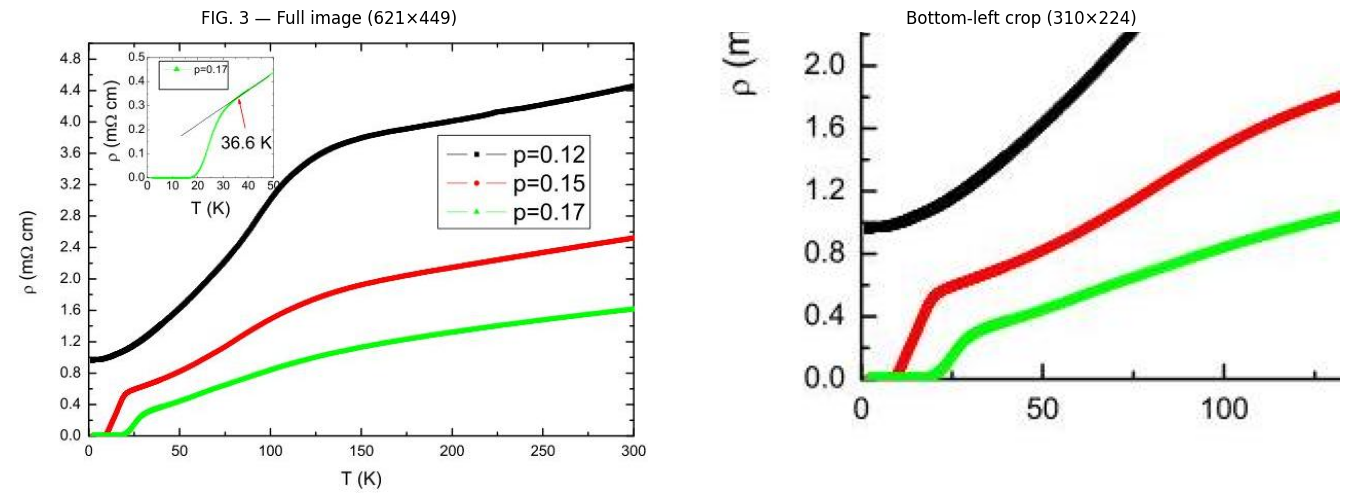

In [322]:
import matplotlib.pyplot as plt
from IPython.display import display

if relevant_plots:
    for idx, plot in relevant_plots:
        fig_obj = plot_figures[idx]
        ref = fig_obj.figure_reference or f"Plot {idx}"

        # Decode full image
        full_bytes = base64.b64decode(fig_obj.base64_data)
        full_img = PILImage.open(io.BytesIO(full_bytes))

        # Crop bottom-left
        w, h = full_img.size
        crop_img = full_img.crop((0, h // 2, w // 2, h))

        # Plot side by side
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(full_img)
        axes[0].set_title(f"{ref} — Full image ({w}×{h})")
        axes[0].axis("off")

        axes[1].imshow(crop_img)
        axes[1].set_title(f"Bottom-left crop ({w//2}×{h//2})")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("[SKIP] No relevant plots to visualise.")



---
## Step 8: Link Plot Series to Materials

In [323]:
# ══════════════════════════════════════════════════════════════════════════
# Step 8: Link VLM series → materials  (SeriesMaterialLinker from pipeline)
# Uses VLM's series names (which have material context) instead of Florence-2's
# color-based names.
# ══════════════════════════════════════════════════════════════════════════

if SKIP_FIGURES or not relevant_plots:
    print("[SKIP] Skipping performance linking")
    plot_mappings = []
else:
    import dspy
    from llm_synthesis.transformers.performance_linking.series_material_linker import (
        SeriesMaterialLinker,
    )
    from llm_synthesis.transformers.performance_linking.base import LinkingInput
    from llm_synthesis.models.performance import PlotMaterialMapping

    print(f"[Step 8] Linking VLM series to {len(materials)} materials (SeriesMaterialLinker)...")

    linker_lm = get_llm_from_name(
        LINKER_MODEL,
        model_kwargs={"temperature": 0.0, "max_tokens": 32000},
    )
    series_linker = SeriesMaterialLinker(lm=linker_lm)

    plot_mappings = []

    for idx, plot in relevant_plots:
        fig = plot_figures[idx]

        # Use VLM's series names (from tc_from_vlm_original) — these have
        # material-aware names like "Re0.88Mo0.12" or "x=0.12" because
        # the VLM received the materials list as context.
        # Florence-2 names are only useful for coordinates, not for linking.
        vlm_series = tc_from_vlm_original.get(idx, {})
        series_names = list(vlm_series.keys())

        if not series_names:
            # Fallback to Florence-2 names if VLM produced nothing for this plot
            series_names = list(plot.name_to_coordinates.keys())
            print(f"\n  Plot {idx}: [FALLBACK] Using Florence-2 names ({len(series_names)} series)")
        else:
            print(f"\n  Plot {idx}: {len(series_names)} VLM series")
        print(f"    Series: {series_names}")

        context = f"{fig.context_before} {fig.context_after}"
        plot_meta = {
            "title": plot.title,
            "x_axis_label": plot.x_axis_label,
            "x_axis_unit": plot.x_axis_unit,
            "y_left_axis_label": plot.y_left_axis_label,
            "y_left_axis_unit": plot.y_left_axis_unit,
        }

        linking_input = LinkingInput(
            materials=materials,
            series_names=series_names,
            context=context,
            plot_metadata=plot_meta,
        )
        validated_mappings = series_linker.forward(linking_input)

        matched_series = {m.series_name for m in validated_mappings}
        unmatched = [s for s in series_names if s not in matched_series]

        plot_mappings.append(PlotMaterialMapping(
            plot_index=idx,
            figure_reference=fig.figure_reference,
            mappings=validated_mappings,
            unmatched_series=unmatched,
        ))

        for m in validated_mappings:
            print(f"    '{m.series_name}' -> '{m.material_name}' ({m.confidence})")
        if unmatched:
            print(f"    [WARN] Unmatched: {unmatched}")

    print(f"\n[OK] Series linking complete: {len(plot_mappings)} plot(s)")

[Step 8] Linking VLM series to 2 materials (SeriesMaterialLinker)...

  Plot 1: 3 VLM series
    Series: ['GdO0.88F0.12FeAs (p=0.12, black curve)', 'GdO0.85F0.15FeAs (p=0.15, red curve)', 'GdO0.83F0.17FeAs (p=0.17, green curve)']
    'GdO0.85F0.15FeAs (p=0.15, red curve)' -> 'GdO0.85F0.15FeAs' (high)
    'GdO0.83F0.17FeAs (p=0.17, green curve)' -> 'GdO0.83F0.17FeAs' (high)
    [WARN] Unmatched: ['GdO0.88F0.12FeAs (p=0.12, black curve)']

[OK] Series linking complete: 1 plot(s)


---
## Step 9: Aggregate & Build Final Results

Combine everything: synthesis + Tc from text + Tc from VLM + R(T) data per material.

In [324]:
from llm_synthesis.utils.performance_utils import aggregate_all_materials_performance
import unicodedata

# ══════════════════════════════════════════════════════════════════════════
# Step 9: Aggregate — Merge text Tc + VLM Tc onto backbone materials
# Uses plot_mappings (SeriesMaterialLinker output) + text_tc_to_material
# ══════════════════════════════════════════════════════════════════════════

from llm_synthesis.utils.formula_utils import (
    normalize_formula as _normalize_formula,
    extract_condition_annotation,
)

def _find_vlm_tc_for_series(series_name: str, vlm_results: dict) -> dict:
    """Fuzzy-match a series name against VLM Tc keys."""
    if series_name in vlm_results:
        return vlm_results[series_name]
    sn_norm = _normalize_formula(series_name)
    for vlm_key, vlm_val in vlm_results.items():
        if _normalize_formula(vlm_key) == sn_norm:
            return vlm_val
        vk = _normalize_formula(vlm_key)
        if sn_norm in vk or vk in sn_norm:
            return vlm_val
    if len(vlm_results) == 1:
        only_val = next(iter(vlm_results.values()))
        only_key = next(iter(vlm_results.keys()))
        print(f"    [FALLBACK] Single-series match: '{series_name}' → '{only_key}'")
        return only_val
    return {}


def _vlm_data_has_tc(vlm_data: dict) -> bool:
    return bool(vlm_data.get("superconducting") and vlm_data.get("tc_mid") is not None)


# ── Fuzzy-match text Tc entries to backbone materials ──
text_tc_to_material = {}  # {text_material_name: backbone_material_name}

for entry in tc_from_text:
    text_mat = entry.get("material", "")
    if not text_mat:
        continue
    text_norm = _normalize_formula(text_mat)
    for m in materials:
        if _normalize_formula(m) == text_norm:
            text_tc_to_material[text_mat] = m
            break

print(f"[Step 9a] Matched {len(text_tc_to_material)}/{len(tc_from_text)} text Tc entries to backbone materials")
for txt_mat, bb_mat in text_tc_to_material.items():
    if txt_mat != bb_mat:
        print(f"    '{txt_mat}' → '{bb_mat}'")


# ── Aggregate performance data (R(T) coordinates) per material ──
if plot_mappings and plots:
    performance_data = aggregate_all_materials_performance(materials, plot_mappings, plots)
else:
    performance_data = {}

# ── Build text Tc per material ──
text_tc_per_material = {}

for entry in tc_from_text:
    text_mat = entry.get("material", "")
    tc_val = entry.get("Tc_mid")
    if tc_val is None and entry.get("T_onset") is None:
        continue

    # Use text_tc_to_material from Step 8b, with direct formula fallback
    target_mat = text_tc_to_material.get(text_mat)
    if not target_mat:
        text_norm = _normalize_formula(text_mat)
        for m in materials:
            if _normalize_formula(m) == text_norm:
                target_mat = m
                break

    if target_mat:
        existing = text_tc_per_material.get(target_mat)
        if existing is None or (tc_val is not None and existing.get("Tc_mid") is None):
            text_tc_per_material[target_mat] = entry
            text_tc_per_material[target_mat]["_all_variants"] = \
                text_tc_per_material.get(target_mat, {}).get("_all_variants", [])
            text_tc_per_material[target_mat]["_all_variants"].append(entry)

# ── Build VLM Tc per material using plot_mappings ──
# Handles multiple conditions (e.g., centrosymmetric vs non-centrosymmetric)
# for the same backbone material.
vlm_tc_per_material = {}
vlm_tc_conditions = {}  # {material_name: [list_of_condition_entries]}

for mapping in plot_mappings:
    plot_idx = mapping.plot_index

    # Get VLM results for this plot — prefer snippet, fallback to original
    snip_results = tc_from_vlm_snippet.get(plot_idx, {})
    orig_results = tc_from_vlm_original.get(plot_idx, {})

    for sm in mapping.mappings:
        # Try to find VLM Tc for this series — prefer snippet source
        vlm_data = None
        source_label = None

        for lookup_dict, label in [(snip_results, "snippet"), (orig_results, "original")]:
            found = _find_vlm_tc_for_series(sm.series_name, lookup_dict)
            if found:
                vlm_data = found
                source_label = label
                break

        if vlm_data and _vlm_data_has_tc(vlm_data):
            tagged = dict(vlm_data)
            tagged["_vlm_source"] = source_label
            tagged["_series_name"] = sm.series_name
            tagged["_plot_idx"] = plot_idx
            tagged["_condition"] = extract_condition_annotation(sm.series_name)

            mat_name = sm.material_name
            if mat_name not in vlm_tc_conditions:
                vlm_tc_conditions[mat_name] = []
            vlm_tc_conditions[mat_name].append(tagged)

# ── Resolve conditions: keep both if genuinely different, pick best otherwise ──
for mat_name, entries in vlm_tc_conditions.items():
    if len(entries) == 1:
        vlm_tc_per_material[mat_name] = entries[0]
        continue

    # Check if entries represent genuinely different conditions
    conditions = [e.get("_condition") for e in entries]
    unique_conditions = {c for c in conditions if c is not None}

    if len(unique_conditions) >= 2:
        # Genuinely different conditions (e.g., "C" and "NC")
        # Store the first as primary, keep all in _all_conditions
        vlm_tc_per_material[mat_name] = entries[0]
        vlm_tc_per_material[mat_name]["_all_conditions"] = entries
        print(f"    [MULTI-CONDITION] {mat_name}: {len(entries)} conditions "
              f"({', '.join(str(c) for c in unique_conditions)})")
    else:
        # Same material, same/no conditions — pick the one closest to text Tc
        text_entry = text_tc_per_material.get(mat_name, {})
        text_tc_val = text_entry.get("Tc_mid")

        if text_tc_val is not None:
            best = min(entries, key=lambda e: abs((e.get("tc_mid") or 0) - text_tc_val))
        else:
            # No text Tc to compare — prefer snippet, then first
            snippet_entries = [e for e in entries if e.get("_vlm_source") == "snippet"]
            best = snippet_entries[0] if snippet_entries else entries[0]

        vlm_tc_per_material[mat_name] = best


# ── Collect unmatched VLM series ──
unmatched_vlm_tc = {}
for mapping in plot_mappings:
    plot_idx = mapping.plot_index
    for series_name in mapping.unmatched_series:
        # Check both snippet and original
        for vlm_dict, label in [(tc_from_vlm_snippet, "snippet"), (tc_from_vlm_original, "original")]:
            if plot_idx in vlm_dict:
                vlm_data = _find_vlm_tc_for_series(series_name, vlm_dict[plot_idx])
                if vlm_data and _vlm_data_has_tc(vlm_data):
                    tagged = dict(vlm_data)
                    tagged["_vlm_source"] = label
                    tagged["_plot_idx"] = plot_idx
                    unmatched_vlm_tc[series_name] = tagged
                    break

# ── Summary Table ──
def _fmt(val, suffix=" K"):
    return f"{val:.1f}{suffix}" if val is not None else "NR"

print("=" * 115)
print(f"{'Material':<35} {'Synth?':<7} {'SC?':<5} {'Tc_text':>10} {'Onset':>10} {'Tc_VLM':>10} {'VLM src':<10} {'Series':<20}")
print("-" * 115)

for material in materials:
    has_synth = any(e.material == material and (e.synthesis is not None or hasattr(e, "_reconciled_synth")) for e in all_syntheses)
    synth_str = "YES" if has_synth else "NO"

    text_entry = text_tc_per_material.get(material, {})
    text_sc = text_entry.get("superconducting", None)
    text_tc = text_entry.get("Tc_mid")
    text_onset = text_entry.get("T_onset")

    vlm_entry = vlm_tc_per_material.get(material, {})
    vlm_sc = vlm_entry.get("superconducting", None)
    vlm_tc = vlm_entry.get("tc_mid")
    vlm_src = vlm_entry.get("_vlm_source", "—")
    vlm_series = vlm_entry.get("_series_name", "—")

    if text_sc is not None:
        sc_str = "YES" if text_sc else "NO"
    elif vlm_sc is not None:
        sc_str = "YES" if vlm_sc else "NO"
    else:
        sc_str = "?"

    print(f"{material:<35} {synth_str:<7} {sc_str:<5} {_fmt(text_tc):>10} {_fmt(text_onset):>10} {_fmt(vlm_tc):>10} {vlm_src:<10} {vlm_series[:20]:<20}")

if unmatched_vlm_tc:
    print("-" * 115)
    print(f"UNMATCHED VLM SERIES ({len(unmatched_vlm_tc)}):")
    for sn, data in unmatched_vlm_tc.items():
        sc = "YES" if data.get("superconducting") else "NO"
        src = data.get("_vlm_source", "?")
        print(f"  {sn:<33} {'':>7} {sc:<5} {'':>10} {'':>10} {_fmt(data.get('tc_mid')):>10} {src:<10}")

print("=" * 115)
n_complete = sum(1 for m in materials 
                 if text_tc_per_material.get(m, {}).get("Tc_mid") is not None 
                 and _vlm_data_has_tc(vlm_tc_per_material.get(m, {})))
print(f"\nMaterials total:       {len(materials)}")
print(f"  with synthesis:      {sum(1 for e in all_syntheses if e.synthesis is not None)}")
print(f"  with text Tc:        {sum(1 for v in text_tc_per_material.values() if v.get('Tc_mid') is not None)}")
print(f"  with VLM Tc:         {sum(1 for v in vlm_tc_per_material.values() if _vlm_data_has_tc(v))}")
print(f"  with R(T) data:      {len(performance_data)}")
print(f"  fully complete:      {n_complete}")
print(f"Unmatched VLM series:  {len(unmatched_vlm_tc)}")


[Step 9a] Matched 2/3 text Tc entries to backbone materials
Material                            Synth?  SC?      Tc_text      Onset     Tc_VLM VLM src    Series              
-------------------------------------------------------------------------------------------------------------------
GdO0.85F0.15FeAs                    YES     YES           NR         NR     17.0 K snippet    GdO0.85F0.15FeAs (p=
GdO0.83F0.17FeAs                    YES     YES           NR     36.6 K     36.5 K snippet    GdO0.83F0.17FeAs (p=
-------------------------------------------------------------------------------------------------------------------
UNMATCHED VLM SERIES (1):
  GdO0.88F0.12FeAs (p=0.12, black curve)         YES                             17.0 K original  

Materials total:       2
  with synthesis:      2
  with text Tc:        0
  with VLM Tc:         2
  with R(T) data:      2
  fully complete:      0
Unmatched VLM series:  1


---
## Step 9b: Reconciliation — Fill Gaps & Resolve Unmatched Entries

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 9b: Reconciliation
# Takes the current material table (with gaps) + unmatched leftovers,
# sends them to the LLM with the paper text, and asks it to:
#   1. Match unmatched VLM series to existing materials
#   2. Fill missing text Tc for materials that have none
#   3. Fill missing VLM Tc by identifying which plot series belongs to which material
#   4. Add genuinely new materials if evidence supports it
#   5. Discard unmatched entries with no clear match
# ══════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("RECONCILIATION — Filling gaps & resolving unmatched entries")
print("=" * 70)

# ── Build the current state summary for the LLM ──

def _build_material_status():
    """Build a text summary of each material and what's missing."""
    lines = []
    for mat in materials:
        has_synth = any(e.material == mat and e.synthesis is not None for e in all_syntheses)
        text_entry = text_tc_per_material.get(mat, {})
        has_text_tc = text_entry.get("Tc_mid") is not None
        vlm_entry = vlm_tc_per_material.get(mat, {})
        has_vlm_tc = _vlm_data_has_tc(vlm_entry)

        gaps = []
        if not has_synth:
            gaps.append("missing synthesis")
        if not has_text_tc:
            gaps.append("missing text Tc")
        if not has_vlm_tc:
            gaps.append("missing VLM Tc")

        status = "COMPLETE" if (has_text_tc and has_vlm_tc) else f"GAPS: {', '.join(gaps)}"

        tc_text_str = f"Tc_text={text_entry.get('Tc_mid')} K" if has_text_tc else "Tc_text=NR"
        tc_vlm_str = f"Tc_vlm={vlm_entry.get('tc_mid')} K" if has_vlm_tc else "Tc_vlm=NR"

        lines.append(f"  {mat}: {tc_text_str}, {tc_vlm_str} [{status}]")
    return "\n".join(lines)


def _build_unmatched_summary():
    """Build a text summary of unmatched VLM series and text Tc entries."""
    lines = []

    # Unmatched VLM series
    if unmatched_vlm_tc:
        lines.append("UNMATCHED VLM SERIES (from R(T) plots, not linked to any material):")
        for sn, data in unmatched_vlm_tc.items():
            tc = data.get("tc_mid")
            tc_str = f"Tc={tc:.1f} K" if tc else "Tc=NR"
            sc = "SC=YES" if data.get("superconducting") else "SC=NO"
            plot_idx = data.get("_plot_idx", "?")
            lines.append(f"  series '{sn}' (Plot {plot_idx}): {sc}, {tc_str}")

    # Unmatched text Tc entries (in tc_from_text but not matched to any material)
    matched_norms = {_normalize_formula(m) for m in text_tc_per_material}
    unmatched_text = [
        e for e in tc_from_text
        if _normalize_formula(e["material"]) not in matched_norms and e.get("Tc_mid") is not None
    ]
    if unmatched_text:
        lines.append("\nUNMATCHED TEXT Tc ENTRIES (from text, not matched to backbone):")
        for e in unmatched_text:
            tc = e.get("Tc_mid")
            tc_str = f"Tc={tc:.1f} K" if tc else "Tc=NR"
            lines.append(f"  {e['material']} [{e.get('condition', 'ambient')}]: {tc_str}")

    # Brief summary of already-matched VLM series (for reference, NOT the full dump)
    if vlm_tc_per_material:
        lines.append("\nALREADY-MATCHED VLM SERIES (for reference):")
        for mat, entry in vlm_tc_per_material.items():
            sn = entry.get("_series_name", "?")
            tc = entry.get("tc_mid")
            tc_str = f"Tc={tc:.1f} K" if tc else "Tc=NR"
            lines.append(f"  '{sn}' -> {mat}: {tc_str}")

    return "\n".join(lines) if lines else "No unmatched entries."


material_status = _build_material_status()
unmatched_summary = _build_unmatched_summary()

# Count gaps
n_missing_text = sum(1 for m in materials if text_tc_per_material.get(m, {}).get("Tc_mid") is None)
n_missing_vlm = sum(1 for m in materials if not _vlm_data_has_tc(vlm_tc_per_material.get(m, {})))
n_unmatched_vlm = len(unmatched_vlm_tc)

print(f"Materials with missing text Tc: {n_missing_text}/{len(materials)}")
print(f"Materials with missing VLM Tc:  {n_missing_vlm}/{len(materials)}")
print(f"Unmatched VLM series:           {n_unmatched_vlm}")

if n_missing_text == 0 and n_missing_vlm == 0 and n_unmatched_vlm == 0:
    print("\n[OK] No gaps or unmatched entries — skipping reconciliation.")
else:
    print("\nSending reconciliation request to LLM...")

    reconciliation_prompt = (
        "You are helping reconcile data extracted from a superconductivity paper.\n\n"
        "We have a list of materials with their current extraction status, and some "
        "unmatched entries that could fill gaps. Your job:\n\n"
        "1. MATCH unmatched VLM series to existing materials if you can identify which "
        "   material a series corresponds to (e.g., 'x=0.40' in a Re_{1-x}Mo_x paper = Re0.60Mo0.40).\n"
        "2. For materials MISSING text Tc: search the paper text below for any Tc values "
        "   for that specific composition. Only report values explicitly stated as numbers.\n"
        "3. For materials MISSING VLM Tc: check if any VLM series (matched or unmatched) "
        "   corresponds to that material.\n"
        "4. If an unmatched entry clearly belongs to a NEW material not in our list, add it.\n"
        "5. If an unmatched entry cannot be confidently matched, mark it as DISCARD.\n\n"
        "FORMULA MATCHING GUIDE:\n"
        "- 'Re0.88Mo0.12' = 'Re_{0.88}Mo_{0.12}' (LaTeX vs plain text are equivalent)\n"
        "- In a Re_{1-x}Mo_x system: 'x=0.12' means Mo content=0.12, so material = Re0.88Mo0.12\n"
        "- Series like 'Re0.82Mo0.18 (x=0.18, red)' match to Re_{0.82}Mo_{0.18} if it exists,\n"
        "  or should be added as ADD_MATERIAL if not in the backbone.\n\n"
        "RULES:\n"
        "- NEVER hallucinate Tc values. Only use numbers explicitly in the paper text.\n"
        "- NEVER force-match if uncertain. Better to DISCARD than to mis-match.\n"
        "- For series-to-material matching, use the paper's notation (e.g., x=0.40 means Mo content).\n\n"
        f"CURRENT MATERIALS AND STATUS:\n{material_status}\n\n"
        f"{unmatched_summary}\n\n"
        "PAPER TEXT (use this to verify matches and find missing Tc values):\n"
        "--- BEGIN PAPER TEXT ---\n"
    )

    # Truncate text to fit context
    MAX_RECON_CHARS = 25_000
    recon_text = text_for_llm[:MAX_RECON_CHARS] if len(text_for_llm) > MAX_RECON_CHARS else text_for_llm

    reconciliation_prompt += recon_text + "\n--- END PAPER TEXT ---\n\n"

    reconciliation_prompt += (
        "OUTPUT FORMAT — one line per action, using pipe-delimited format:\n"
        "ACTION | material_formula | field | value | source | reasoning\n\n"
        "Where ACTION is one of:\n"
        "  MATCH_VLM    — link an unmatched VLM series to a material\n"
        "  FILL_TEXT_TC  — fill missing text Tc from paper text\n"
        "  FILL_VLM_TC  — assign a VLM series Tc to a material\n"
        "  FILL_SYNTH   — describe the synthesis method for a material missing it\n"
        "  ADD_MATERIAL  — add a new material not in the current list\n"
        "  DISCARD       — unmatched entry with no clear match\n\n"
        "For FILL_TEXT_TC, use field names: T_onset, Tc_mid, T_zero, delta_Tc\n"
        "For FILL_SYNTH, put the synthesis method in field and description in value\n"
        "For MATCH_VLM and FILL_VLM_TC, put the series name in 'source'\n\n"
        "Examples:\n"
        "MATCH_VLM | Re0.50Mo0.50 | tc_mid | 8.5 | x=0.50 (green) / Plot 3 | x=0.50 in Re_{1-x}Mo_x = Re0.50Mo0.50\n"
        "FILL_TEXT_TC | Re0.55Mo0.45 | Tc_mid | 6.6 | paper text Table 1 | Table 1 lists Tc=6.6K for x=0.45\n"
        "FILL_TEXT_TC | Re0.55Mo0.45 | T_onset | 7.0 | paper text p.4 | onset at 7.0 K mentioned on page 4\n"
        "ADD_MATERIAL | Re0.50Mo0.50 | Tc_mid | 8.5 | x=0.50 (green) / Plot 3 | new composition not in original list\n"
        "DISCARD | — | — | — | x=0.99 unknown series | cannot identify which material this is\n\n"
        "List ALL actions. If nothing to do for a gap, explain why in a DISCARD line."
    )

    recon_lm = get_llm_from_name(
        GEMINI_MODEL,
        model_kwargs={"temperature": 0.0, "max_tokens": 30000},
    )
    recon_sig = make_dspy_text_extractor_signature(
        signature_name="Reconciliation",
        instructions=reconciliation_prompt,
        input_description="Reconciliation context (embedded in instructions).",
        output_name="actions",
        output_description="One ACTION line per reconciliation decision, pipe-delimited.",
    )
    recon_extractor = DspyTextExtractor(signature=recon_sig, lm=recon_lm)

    try:
        recon_raw = recon_extractor.forward(input="Perform reconciliation as described above.")
    except Exception as e:
        print(f"[WARN] Reconciliation LLM call failed: {e}")
        recon_raw = ""

    print(f"\n{'=' * 70}")
    print("RECONCILIATION ACTIONS (raw LLM output)")
    print("=" * 70)
    print(recon_raw)

    # ── Parse reconciliation actions ──
    n_matched = 0
    n_filled_text = 0
    n_filled_vlm = 0
    n_added = 0
    n_discarded = 0

    for line in recon_raw.strip().split("\n"):
        line = line.strip()
        if not line or "|" not in line:
            continue
        parts = [p.strip() for p in line.split("|")]
        if len(parts) < 4:
            continue

        action = parts[0].upper()
        mat = parts[1].strip() if len(parts) > 1 else ""
        field = parts[2].strip().lower() if len(parts) > 2 else ""
        value_str = parts[3].strip() if len(parts) > 3 else ""
        source = parts[4].strip() if len(parts) > 4 else ""
        reasoning = parts[5].strip() if len(parts) > 5 else ""

        # Parse numeric value
        val_match = re.match(r"(\d+\.?\d*)", value_str)
        val = float(val_match.group(1)) if val_match else None

        # Resolve mat to backbone material name if possible (prevents duplicates)
        if mat and mat != "—":
            mat_norm = _normalize_formula(mat)
            for backbone_mat in materials:
                if _normalize_formula(backbone_mat) == mat_norm:
                    mat = backbone_mat
                    break

        if action == "DISCARD":
            n_discarded += 1
            print(f"  [DISCARD] {source}: {reasoning}")
            continue

        if action in ("MATCH_VLM", "FILL_VLM_TC"):
            if mat and val is not None:
                # Find or create VLM entry for this material
                if mat not in vlm_tc_per_material:
                    vlm_tc_per_material[mat] = {"superconducting": True, "_vlm_source": "reconciled"}
                entry = vlm_tc_per_material[mat]
                if field in ("tc_mid", "tc"):
                    entry["tc_mid"] = val
                elif field == "t_onset":
                    entry["t_onset"] = val
                elif field == "t_zero":
                    entry["t_zero"] = val
                elif field == "delta_tc":
                    entry["delta_tc"] = val
                entry["_reconciled_from"] = source
                entry["_reconciled_reason"] = reasoning
                n_matched += 1
                print(f"  [MATCH_VLM] {mat}: {field}={val} K (from '{source}')")

        elif action == "FILL_TEXT_TC":
            if mat and val is not None:
                if mat not in text_tc_per_material:
                    text_tc_per_material[mat] = {
                        "material": mat, "condition": "ambient",
                        "superconducting": True, "T_onset": None,
                        "Tc_mid": None, "T_zero": None, "delta_Tc": None,
                    }
                entry = text_tc_per_material[mat]
                if field in ("tc_mid", "tc"):
                    entry["Tc_mid"] = val
                elif field == "t_onset":
                    entry["T_onset"] = val
                elif field == "t_zero":
                    entry["T_zero"] = val
                elif field == "delta_tc":
                    entry["delta_Tc"] = val
                entry["superconducting"] = True
                entry["_reconciled_from"] = source
                n_filled_text += 1
                print(f"  [FILL_TEXT] {mat}: {field}={val} K (from '{source}')")

        elif action == "FILL_SYNTH":
            if mat:
                # Store synthesis info for later — we mark it as reconciled
                for entry in all_syntheses:
                    if entry.material == mat and entry.synthesis is None:
                        entry._reconciled_synth = f"{field}: {value_str}"
                        print(f"  [FILL_SYNTH] {mat}: {field} = {value_str} (from '{source}')")
                        break
                else:
                    print(f"  [FILL_SYNTH] {mat}: material not in all_syntheses, skipping")

        elif action == "ADD_MATERIAL":
            if mat and mat not in materials:
                materials.append(mat)
                # Add a synthesis placeholder
                from llm_synthesis.models.paper import SynthesisEntry
                all_syntheses.append(SynthesisEntry(
                    material=mat, synthesis=None, evaluation=None,
                ))
                # Add VLM or text Tc if provided
                if val is not None:
                    if "vlm" in field or "vlm" in source.lower():
                        vlm_tc_per_material[mat] = {
                            "superconducting": True, "tc_mid": val,
                            "_vlm_source": "reconciled", "_reconciled_from": source,
                        }
                    else:
                        text_tc_per_material[mat] = {
                            "material": mat, "condition": "ambient",
                            "superconducting": True, "Tc_mid": val,
                            "T_onset": None, "T_zero": None, "delta_Tc": None,
                            "_reconciled_from": source,
                        }
                n_added += 1
                print(f"  [ADD] {mat}: {field}={val} K (from '{source}')")

    # Clean up unmatched_vlm_tc — remove entries that were matched
    for mat, entry in vlm_tc_per_material.items():
        reconciled_source = entry.get("_reconciled_from", "")
        for sn in list(unmatched_vlm_tc.keys()):
            if sn in reconciled_source:
                del unmatched_vlm_tc[sn]

    print(f"\n{'=' * 70}")
    print(f"RECONCILIATION SUMMARY")
    print(f"  VLM series matched:    {n_matched}")
    print(f"  Text Tc filled:        {n_filled_text}")
    print(f"  New materials added:   {n_added}")
    print(f"  Discarded:             {n_discarded}")
    print(f"  Remaining unmatched:   {len(unmatched_vlm_tc)}")
    print(f"{'=' * 70}")

    # ── Updated summary table ──
    print(f"\n{'=' * 100}")
    print("UPDATED MATERIAL TABLE (after reconciliation)")
    print("=" * 100)
    print(f"{'Material':<40} {'SC?':<5} {'Tc_text':>10} {'Onset':>10} {'Tc_VLM':>10} {'VLM src':<12}")
    print("-" * 100)

    for material in materials:
        text_entry = text_tc_per_material.get(material, {})
        text_tc = text_entry.get("Tc_mid")
        text_onset = text_entry.get("T_onset")
        text_sc = text_entry.get("superconducting")
        recon_t = " ★" if text_entry.get("_reconciled_from") else ""

        vlm_entry = vlm_tc_per_material.get(material, {})
        vlm_tc = vlm_entry.get("tc_mid")
        vlm_sc = vlm_entry.get("superconducting")
        vlm_src = vlm_entry.get("_vlm_source", "—")
        recon_v = " ★" if vlm_entry.get("_reconciled_from") else ""

        if text_sc is not None:
            sc_str = "YES" if text_sc else "NO"
        elif vlm_sc is not None:
            sc_str = "YES" if vlm_sc else "NO"
        else:
            sc_str = "?"

        print(f"{material:<40} {sc_str:<5} {_fmt(text_tc):>10}{recon_t} {_fmt(text_onset):>10} {_fmt(vlm_tc):>10}{recon_v} {vlm_src:<12}")

    print("-" * 100)
    print("★ = filled by reconciliation step")


RECONCILIATION — Filling gaps & resolving unmatched entries
Materials with missing text Tc: 2/2
Materials with missing VLM Tc:  0/2
Unmatched VLM series:           1

Sending reconciliation request to LLM...


2026/02/24 19:13:15 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


---
## Step 10: Save Results

In [ ]:
from llm_synthesis.utils.performance_utils import sanitize_filename

paper_dir = os.path.join(OUTPUT_DIR, paper.id)
os.makedirs(paper_dir, exist_ok=True)

# Build and save per-material results
final_results = []

for entry in all_syntheses:
    mat = entry.material

    # Tc from text (fuzzy-matched)
    text_entry = text_tc_per_material.get(mat, {})
    text_tc_clean = {k: v for k, v in text_entry.items() if not k.startswith("_")}

    # Tc from VLM (best of snippet/original)
    vlm_entry = vlm_tc_per_material.get(mat, {})

    result = {
        "material": mat,
        "synthesis": entry.synthesis.model_dump() if entry.synthesis else None,
        "evaluation": entry.evaluation.model_dump() if entry.evaluation else None,
        "tc_from_text": text_tc_clean if text_tc_clean else None,
        "tc_from_text_all_variants": [
            {k: v for k, v in variant.items() if not k.startswith("_")}
            for variant in text_entry.get("_all_variants", [])
        ] or None,
        "tc_from_vlm": {
            "superconducting": vlm_entry.get("superconducting"),
            "T_onset": vlm_entry.get("t_onset"),
            "Tc_mid": vlm_entry.get("tc_mid"),
            "T_zero": vlm_entry.get("t_zero"),
            "Delta_Tc": vlm_entry.get("delta_tc"),
            "source": vlm_entry.get("_vlm_source"),
        } if vlm_entry else None,
        "performance": (
            performance_data[mat].model_dump()
            if mat in performance_data
            else None
        ),
    }
    final_results.append(result)

    # Save individual material file
    mat_name = sanitize_filename(mat)
    mat_path = os.path.join(paper_dir, f"{mat_name}.json")
    with open(mat_path, "w") as f:
        json.dump(result, f, indent=2, default=str)

# Save plot mappings
if plot_mappings:
    with open(os.path.join(paper_dir, "performance_mappings.json"), "w") as f:
        json.dump([m.model_dump() for m in plot_mappings], f, indent=2)

# Save Tc summary
tc_summary = {
    "paper_id": paper.id,
    "materials": materials,    
    "tc_from_text_raw": [
        {k: v for k, v in entry.items() if not k.startswith("_")}
        for entry in tc_from_text
    ],

    "tc_from_text_matched": {
        k: {kk: vv for kk, vv in v.items() if not kk.startswith("_")}
        for k, v in text_tc_per_material.items()
    },
    "tc_from_vlm_per_material": {
        k: {kk: vv for kk, vv in v.items() if not isinstance(vv, (list, dict)) and not kk.startswith("_")}
        for k, v in vlm_tc_per_material.items()
    },
    "tc_from_vlm_unmatched": {
        k: {kk: vv for kk, vv in v.items() if not isinstance(vv, (list, dict)) and not kk.startswith("_")}
        for k, v in unmatched_vlm_tc.items()
    },
}
with open(os.path.join(paper_dir, "tc_summary.json"), "w") as f:
    json.dump(tc_summary, f, indent=2, default=str)

# Save overall summary
summary = {
    "paper_id": paper.id,
    "paper_name": paper.name,
    "total_materials": len(materials),
    "materials_list": materials,
    "total_plots_extracted": len(plots) if not SKIP_FIGURES else 0,
    "rt_plots_found": len(relevant_plots) if not SKIP_FIGURES else 0,
    "materials_with_text_tc": sum(1 for v in text_tc_per_material.values() if v.get("Tc_mid") is not None),
    "materials_with_vlm_tc": sum(1 for v in vlm_tc_per_material.values() if _vlm_data_has_tc(v)),
    "unmatched_series_with_tc": len(unmatched_vlm_tc),
    "materials_with_rt_data": len(performance_data),
}
with open(os.path.join(paper_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"[OK] Results saved to: {paper_dir}/")
print(f"   - {len(final_results)} material files")
print(f"   - tc_summary.json")
print(f"   - summary.json")
if plot_mappings:
    print(f"   - performance_mappings.json")


[OK] Results saved to: /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/data/pdf_papers/superconductor_pdfs-random-sample/selected_papers/results/0801.2629_0801.2629v2/
   - 6 material files
   - tc_summary.json
   - summary.json
   - performance_mappings.json


---
## Step 11: Export Flat Records + Append to Master CSV

Build one standardized record per material (flat, CSV-friendly) for multi-paper
aggregation. Each run appends to `MASTER_CSV` — duplicates are handled by the
`(paper_id, material)` composite key.

In [ ]:
import csv
from pathlib import Path

# ── Helpers ──

def extract_year_from_arxiv_id(paper_id: str) -> int | None:
    """Extract publication year from arXiv ID."""
    clean = paper_id.split("_")[0]
    clean = re.sub(r'v\d+$', '', clean)
    match = re.match(r'^(\d{2})(\d{2})\.\d+$', clean)
    if match:
        yy = int(match.group(1))
        year = 2000 + yy if yy < 90 else 1900 + yy
        return year
    return None


def normalize_formula_for_csv(s: str) -> str:
    """Normalize a material formula for cross-paper deduplication."""
    base = s.strip()
    # Strip LaTeX: \mathrm{Re} → Re, _{0.12} → 0.12
    base = re.sub(r'\\(?:mathrm|text|textit|mathit|mathbf)\{([^}]*)\}', r'\1', base)
    base = re.sub(r'[_^]\{([^}]*)\}', r'\1', base)
    base = base.replace('$', '').replace('\\', '')
    base = re.sub(r'\s*\([^)]*\)\s*$', '', base).strip()
    sub_map = {'₀': '0', '₁': '1', '₂': '2', '₃': '3', '₄': '4',
               '₅': '5', '₆': '6', '₇': '7', '₈': '8', '₉': '9',
               '₋': '-', '₊': '+', '₍': '(', '₎': ')'}
    for uni, asc in sub_map.items():
        base = base.replace(uni, asc)
    base = base.replace('δ', 'delta').replace('Δ', 'Delta')
    base = base.replace('−', '-').replace('–', '-')
    return base.strip()


def pick_best_tc(text_tc, vlm_tc_snip, vlm_tc_orig, text_onset):
    """Pick best Tc. Priority: snippet VLM > original VLM > text Tc_mid > text T_onset."""
    if vlm_tc_snip is not None:
        return vlm_tc_snip, "vlm_snippet"
    if vlm_tc_orig is not None:
        return vlm_tc_orig, "vlm_original"
    if text_tc is not None:
        return text_tc, "text"
    if text_onset is not None:
        return text_onset, "text_onset"
    return None, "none"


# ── Build flat records ──

COLUMNS = [
    "paper_id", "year", "material", "material_normalized", "condition",
    "is_superconductor",
    "tc_text", "tc_text_onset", "tc_text_zero", "tc_text_delta", "tc_text_source",
    "tc_vlm_snip", "tc_vlm_snip_onset", "tc_vlm_snip_zero",
    "tc_vlm_orig", "tc_vlm_orig_onset", "tc_vlm_orig_zero",
    "tc_vlm_source",
    "tc_best", "tc_best_source",
    "has_text_tc", "has_vlm_tc", "has_synthesis",
    "synthesis_method", "synthesis_score",
]

year = extract_year_from_arxiv_id(paper.id)
flat_records = []

# ── Build records from all_syntheses (Step 1 materials) ──
materials_in_records = set()

for entry in all_syntheses:
    mat = entry.material
    materials_in_records.add(_normalize_formula(mat))

    # Text Tc (best match from multi-condition list)
    text_entry = text_tc_per_material.get(mat, {})
    text_tc = text_entry.get("Tc_mid")
    text_onset = text_entry.get("T_onset")
    text_zero = text_entry.get("T_zero")
    text_delta = text_entry.get("delta_Tc")
    text_sc = text_entry.get("superconducting")
    text_cond = text_entry.get("condition", "ambient")

    # VLM Tc — look up BOTH snippet and original independently
    vlm_entry = vlm_tc_per_material.get(mat, {})
    vlm_src = vlm_entry.get("_vlm_source", "")
    vlm_sc = vlm_entry.get("superconducting")

    # Find this material's series name and plot index to look up both VLM dicts
    series_name = vlm_entry.get("_series_name", "")
    plot_idx = vlm_entry.get("_plot_idx")

    # Look up snippet Tc directly from tc_from_vlm_snippet
    vlm_snip_tc = vlm_snip_onset = vlm_snip_zero = None
    if plot_idx is not None and plot_idx in tc_from_vlm_snippet:
        snip_data = _find_vlm_tc_for_series(series_name, tc_from_vlm_snippet[plot_idx])
        if snip_data and snip_data.get("tc_mid") is not None:
            vlm_snip_tc = snip_data.get("tc_mid")
            vlm_snip_onset = snip_data.get("t_onset")
            vlm_snip_zero = snip_data.get("t_zero")

    # Look up original Tc directly from tc_from_vlm_original
    vlm_orig_tc = vlm_orig_onset = vlm_orig_zero = None
    if plot_idx is not None and plot_idx in tc_from_vlm_original:
        orig_data = _find_vlm_tc_for_series(series_name, tc_from_vlm_original[plot_idx])
        if orig_data and orig_data.get("tc_mid") is not None:
            vlm_orig_tc = orig_data.get("tc_mid")
            vlm_orig_onset = orig_data.get("t_onset")
            vlm_orig_zero = orig_data.get("t_zero")

    # Is superconductor?
    if text_sc is not None:
        is_sc = text_sc
    elif vlm_sc is not None:
        is_sc = vlm_sc
    else:
        is_sc = None

    # Best Tc
    tc_best, tc_best_source = pick_best_tc(text_tc, vlm_snip_tc, vlm_orig_tc, text_onset)

    # Synthesis info
    synth_method = (entry.synthesis.synthesis_method if entry.synthesis 
                       else getattr(entry, "_reconciled_synth", None))
    synth_score = (entry.evaluation.scores.overall_score
                   if entry.evaluation and entry.evaluation.scores else None)

    record = {
        "paper_id": paper.id,
        "year": year,
        "material": mat,
        "material_normalized": normalize_formula_for_csv(mat),
        "condition": text_cond,
        "is_superconductor": is_sc,
        "tc_text": text_tc,
        "tc_text_onset": text_onset,
        "tc_text_zero": text_zero,
        "tc_text_delta": text_delta,
        "tc_text_source": text_cond,
        "tc_vlm_snip": vlm_snip_tc,
        "tc_vlm_snip_onset": vlm_snip_onset,
        "tc_vlm_snip_zero": vlm_snip_zero,
        "tc_vlm_orig": vlm_orig_tc,
        "tc_vlm_orig_onset": vlm_orig_onset,
        "tc_vlm_orig_zero": vlm_orig_zero,
        "tc_vlm_source": vlm_src or None,
        "tc_best": tc_best,
        "tc_best_source": tc_best_source,
        "has_text_tc": text_tc is not None,
        "has_vlm_tc": vlm_entry.get("tc_mid") is not None,
        "has_synthesis": entry.synthesis is not None or hasattr(entry, "_reconciled_synth"),
        "synthesis_method": synth_method,
        "synthesis_score": synth_score,
    }
    flat_records.append(record)

# ── Add text-only materials (from tc_from_text but NOT in Step 1 materials) ──
for tc_entry in tc_from_text:
    mat_norm = _normalize_formula(tc_entry["material"])
    if mat_norm not in materials_in_records and tc_entry.get("Tc_mid") is not None:
        materials_in_records.add(mat_norm)
        record = {
            "paper_id": paper.id,
            "year": year,
            "material": tc_entry["material"],
            "material_normalized": normalize_formula_for_csv(tc_entry["material"]),
            "condition": tc_entry.get("condition", "ambient"),
            "is_superconductor": tc_entry.get("superconducting"),
            "tc_text": tc_entry.get("Tc_mid"),
            "tc_text_onset": tc_entry.get("T_onset"),
            "tc_text_zero": tc_entry.get("T_zero"),
            "tc_text_delta": tc_entry.get("delta_Tc"),
            "tc_text_source": tc_entry.get("condition", "ambient"),
            "tc_vlm_snip": None, "tc_vlm_snip_onset": None, "tc_vlm_snip_zero": None,
            "tc_vlm_orig": None, "tc_vlm_orig_onset": None, "tc_vlm_orig_zero": None,
            "tc_vlm_source": None,
            "tc_best": tc_entry.get("Tc_mid"),
            "tc_best_source": "text",
            "has_text_tc": True,
            "has_vlm_tc": False,
            "has_synthesis": False,
            "synthesis_method": None,
            "synthesis_score": None,
        }
        flat_records.append(record)

# ── Add VLM-only materials (unmatched series with Tc) ──
for series_name, vlm_data in unmatched_vlm_tc.items():
    sn_norm = _normalize_formula(series_name)
    if sn_norm not in materials_in_records:
        materials_in_records.add(sn_norm)
        src = vlm_data.get("_vlm_source", "unknown")
        tc_val = vlm_data.get("tc_mid")
        record = {
            "paper_id": paper.id,
            "year": year,
            "material": series_name,
            "material_normalized": normalize_formula_for_csv(series_name),
            "condition": "ambient",
            "is_superconductor": vlm_data.get("superconducting"),
            "tc_text": None, "tc_text_onset": None, "tc_text_zero": None,
            "tc_text_delta": None, "tc_text_source": None,
            "tc_vlm_snip": tc_val if src == "snippet" else None,
            "tc_vlm_snip_onset": vlm_data.get("t_onset") if src == "snippet" else None,
            "tc_vlm_snip_zero": vlm_data.get("t_zero") if src == "snippet" else None,
            "tc_vlm_orig": tc_val if src == "original" else None,
            "tc_vlm_orig_onset": vlm_data.get("t_onset") if src == "original" else None,
            "tc_vlm_orig_zero": vlm_data.get("t_zero") if src == "original" else None,
            "tc_vlm_source": src,
            "tc_best": tc_val,
            "tc_best_source": f"vlm_{src}",
            "has_text_tc": False,
            "has_vlm_tc": tc_val is not None,
            "has_synthesis": False,
            "synthesis_method": None,
            "synthesis_score": None,
        }
        flat_records.append(record)

# ── Drop rows with no Tc data ──
flat_records = [r for r in flat_records if r.get("tc_best") is not None]

# ── Save per-paper JSONL ──
jsonl_path = os.path.join(paper_dir, "tc_flat_records.jsonl")
with open(jsonl_path, "w") as f:
    for rec in flat_records:
        f.write(json.dumps(rec, default=str) + "\n")
print(f"[OK] Saved {len(flat_records)} flat records → {jsonl_path}")

# ── Append to master CSV ──
master_path = Path(MASTER_CSV)
master_path.parent.mkdir(parents=True, exist_ok=True)

existing_keys = set()
if master_path.exists():
    with open(master_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            existing_keys.add((row.get("paper_id", ""), row.get("material", "")))

new_records = [r for r in flat_records
               if (r["paper_id"], r["material"]) not in existing_keys]
replaced_records = [r for r in flat_records
                    if (r["paper_id"], r["material"]) in existing_keys]

if replaced_records:
    replace_keys = {(r["paper_id"], r["material"]) for r in replaced_records}
    all_rows = []
    if master_path.exists():
        with open(master_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            all_rows = [row for row in reader
                        if (row.get("paper_id", ""), row.get("material", "")) not in replace_keys]
    all_rows.extend({k: (str(v) if v is not None else "") for k, v in r.items()}
                    for r in flat_records)
    with open(master_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=COLUMNS, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(all_rows)
    print(f"[OK] Master CSV updated (replaced {len(replaced_records)} + added {len(new_records)} new) → {master_path}")
else:
    write_header = not master_path.exists() or master_path.stat().st_size == 0
    with open(master_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=COLUMNS, extrasaction="ignore")
        if write_header:
            writer.writeheader()
        for rec in flat_records:
            writer.writerow({k: (str(v) if v is not None else "") for k, v in rec.items()})
    print(f"[OK] Appended {len(new_records)} records to master CSV → {master_path}")

# ── Display flat records ──
print(f"\n{'=' * 120}")
print(f"FLAT RECORDS (paper_id={paper.id}, year={year})")
print("=" * 120)
print(f"{'Material':<35} {'Cond':<15} {'SC?':<5} {'Tc_text':>8} {'Tc_snip':>8} {'Tc_orig':>8} {'Tc_best':>8} {'Source':<12} {'Synth?':<7} {'Method':<15}")
print("-" * 130)
for rec in flat_records:
    sc = "YES" if rec["is_superconductor"] else ("NO" if rec["is_superconductor"] is False else "?")
    tc_t = f"{rec['tc_text']:.1f}" if rec["tc_text"] else "—"
    tc_s = f"{rec['tc_vlm_snip']:.1f}" if rec["tc_vlm_snip"] else "—"
    tc_o = f"{rec['tc_vlm_orig']:.1f}" if rec["tc_vlm_orig"] else "—"
    tc_b = f"{rec['tc_best']:.1f}" if rec["tc_best"] else "—"
    src = rec["tc_best_source"]
    has_synth = "YES" if rec.get("has_synthesis") else "NO"
    synth = (rec["synthesis_method"] or "—")[:14]
    cond = (rec.get("condition") or "ambient")[:14]
    print(f"{rec['material']:<35} {cond:<15} {sc:<5} {tc_t:>8} {tc_s:>8} {tc_o:>8} {tc_b:>8} {src:<12} {has_synth:<7} {synth:<15}")


[OK] Saved 6 flat records → /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/data/pdf_papers/superconductor_pdfs-random-sample/selected_papers/results/0801.2629_0801.2629v2/tc_flat_records.jsonl
[OK] Master CSV updated (replaced 6 + added 0 new) → /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/data/pdf_papers/superconductor_pdfs-random-sample/selected_papers/results/tc_master.csv

FLAT RECORDS (paper_id=0801.2629_0801.2629v2, year=2008)
Material                            Cond            SC?    Tc_text  Tc_snip  Tc_orig  Tc_best Source       Synth?  Method         
----------------------------------------------------------------------------------------------------------------------------------
MgB2                                ambient         YES       38.0     37.5     37.5     37.5 vlm_snippet  YES     solid-state    
Mg0.96Al0.04B2                      ambient         YES          —     35.5     35.5  

---

## Done!

Results include for each material:
- **Synthesis procedure** (GeneralSynthesisOntology)
- **Tc from text** (values explicitly reported in the paper)
- **Tc from VLM** (T_onset, Tc_mid, T_zero from geometric construction on R(T) plots)
- **R(T) performance data** (full (T, R) coordinates linked to materials)

---
## Original vs Snippet — Side-by-Side Comparison

Compare VLM Tc results: **original** (single image) vs **snippet** (full + bottom-left crop).

In [ ]:
# ── Compare tc_from_vlm_original vs tc_from_vlm_snippet ──

all_plot_indices = sorted(set(list(tc_from_vlm_original.keys()) + list(tc_from_vlm_snippet.keys())))

if not all_plot_indices:
    print("[WARN] No VLM Tc results to compare.")
else:
    print(f"{'Series':<35} | {'Orig Tc':>8} {'Snip Tc':>8} {'Δ':>7} | {'Orig SC':>7} {'Snip SC':>7} | {'Orig src':<13} {'Snip src':<13}")
    print("-" * 115)

    all_diffs = []

    for plot_idx in all_plot_indices:
        orig = tc_from_vlm_original.get(plot_idx, {})
        snip = tc_from_vlm_snippet.get(plot_idx, {})
        all_series = sorted(set(list(orig.keys()) + list(snip.keys())))

        fig_ref = f"Plot {plot_idx}"
        for i, (idx, _) in enumerate(relevant_plots):
            if idx == plot_idx:
                fig_ref = plot_figures[idx].figure_reference or fig_ref
                break

        print(f"\n  ── {fig_ref} ──")
        for sn in all_series:
            o = orig.get(sn, {})
            s = snip.get(sn, {})

            o_tc = o.get("tc_mid")
            s_tc = s.get("tc_mid")
            o_sc = "Y" if o.get("superconducting") else "N"
            s_sc = "Y" if s.get("superconducting") else "N"
            o_src = o.get("source", "—") if o else "—"
            s_src = s.get("source", "—") if s else "—"

            o_str = f"{o_tc:.1f}" if o_tc else "—"
            s_str = f"{s_tc:.1f}" if s_tc else "—"

            if o_tc is not None and s_tc is not None:
                d = s_tc - o_tc
                d_str = f"{d:+.1f}"
                all_diffs.append(d)
            else:
                d_str = "—"

            print(f"  {sn:<33} | {o_str:>8} {s_str:>8} {d_str:>7} | {o_sc:>7} {s_sc:>7} | {o_src:<13} {s_src:<13}")

    # ── Summary ──
    print(f"\n{'=' * 70}")
    n_orig = sum(1 for pi in all_plot_indices for v in tc_from_vlm_original.get(pi, {}).values() if v.get("tc_mid") is not None)
    n_snip = sum(1 for pi in all_plot_indices for v in tc_from_vlm_snippet.get(pi, {}).values() if v.get("tc_mid") is not None)
    print(f"Series with Tc_mid:  original={n_orig},  snippet={n_snip}")

    if all_diffs:
        import numpy as np
        d = np.array(all_diffs)
        print(f"\nΔ (snippet − original) where both have Tc  (n={len(d)}):")
        print(f"  Mean:   {np.mean(d):+.2f} K")
        print(f"  Median: {np.median(d):+.2f} K")
        print(f"  MAE:    {np.mean(np.abs(d)):.2f} K")
        print(f"  Max|Δ|: {np.max(np.abs(d)):.2f} K")


Series                              |  Orig Tc  Snip Tc       Δ | Orig SC Snip SC | Orig src      Snip src     
-------------------------------------------------------------------------------------------------------------------

  ── Fig. 2 ──
  AlB2 (x=1.0)                      |        —        —       — |       N       N | —             —            
  Mg0.6Al0.4B2 (x=0.40)             |      8.5      8.0    -0.5 |       Y       Y | main plot (cross-checked with inset) bottom-left crop
  Mg0.75Al0.25B2 (x=0.25)           |     19.5     19.0    -0.5 |       Y       Y | inset (magnetization onset ~20 K) bottom-left crop
  Mg0.8Al0.2B2 (x=0.20)             |     25.5     24.0    -1.5 |       Y       Y | main plot (cross-checked with inset) bottom-left crop
  Mg0.96Al0.04B2 (x=0.04)           |     35.5     35.5    +0.0 |       Y       Y | main plot (cross-checked with inset) bottom-left crop
  Mg0.9Al0.1B2 (x=0.10)             |     31.5     31.0    -0.5 |       Y       Y | main plot (